<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>Hypothesis 2 검정: 고성능 GPU일수록 BTC 가격 변동에 더 민감한가</mark></b></span><br><br>
<b>[가설]</b><br>
Hypo 2는 high GPU가 BTC 수익률 변화에 mid/low보다 더 크게 반응하는지를 검정한다. 평균 수익률 차이가 아니라 <b>BTC 민감도 차이</b>가 핵심이므로, 본검정은 성능군 dummy와 BTC lag의 상호작용 회귀로 수행한다.<br><br>
<b>[기준항]</b><br>
low 그룹은 제품 수와 matched product 수가 작아 기준항으로 두면 표준오차가 커질 수 있다. 따라서 본모형은 표본이 충분하고 시장 주력군에 가까운 <b>mid 그룹을 기준항</b>으로 둔다. high-vs-low는 별도 contrast로 확인한다.<br><br>
<b>[성능군 기준]</b><br>
본분석은 <code>chip_perf_group</code>을 사용한다. high는 RTX/RX 80급 이상 및 일부 70 Ti/Super급, mid는 RTX/RX 60급·70급 일반형과 GTX 1660 이상, low는 GT 계열·GTX 1660 미만·RX 하위급 등으로 둔다. VRAM 기준은 12GB 이상 high, 6GB 초과~12GB 미만 mid, 6GB 이하 low로 만든 보조 proxy이다.<br><br>
<b>[VRAM 해석]</b><br>
VRAM과 chip 성능군은 약 1/4 정도 불일치할 수 있다. 따라서 VRAM에서 유의한 신호가 나와도 이를 고성능 chip 효과로 바로 해석하지 않고, 메모리 용량 또는 메모리 집약적 작업 수요의 별도 신호로 분리한다.<br><br>
<b>[보완 분석]</b><br>
0~8주 lag 전체 모형 외에 lag-window, Almon distributed lag, no-trim, 제품구성 통제, product FE를 함께 확인한다. 최종 판단은 개별 lag p-value가 아니라 공동검정과 누적효과 중심으로 한다.<br><br>
</div>

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.oneway import anova_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

OUT = Path("outputs")
H1_DIR = OUT / "hypo1"
H2_DIR = OUT / "hypo2"
H2_DIR.mkdir(parents=True, exist_ok=True)

L = 8
GROUPS = ["high", "mid", "low"]
BASE = "mid"  # 메인 기준항: 표본이 충분한 mid 그룹

MKT_FILE = H1_DIR / "reg.csv"

plt.rcParams["font.family"] = 'MalGun Gothic'
plt.rcParams["axes.unicode_minus"] = False

import re as _re
from datetime import datetime as _dt

FIG_DIR = Path("output_pic") / "hypo_2"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def _safe_fname(text, max_len=120):
    text = str(text).strip()
    text = _re.sub(r"[\\/:*?\"<>|]+", "_", text)
    text = _re.sub(r"\s+", "_", text)
    text = _re.sub(r"_+", "_", text).strip("._ ")
    if not text:
        text = "plot"
    return text[:max_len]

def _infer_title(fig=None):
    fig = fig or plt.gcf()
    if getattr(fig, "_suptitle", None) is not None:
        t = fig._suptitle.get_text()
        if t:
            return t
    for ax in fig.axes:
        t = ax.get_title()
        if t:
            return t
    for ax in fig.axes:
        ylabel = ax.get_ylabel()
        xlabel = ax.get_xlabel()
        if ylabel or xlabel:
            return f"{ylabel}_vs_{xlabel}".strip("_vs_")
    return "plot_" + _dt.now().strftime("%Y%m%d_%H%M%S")

def save_plot(name=None, folder=None, dpi=300):
    folder = Path(folder) if folder is not None else FIG_DIR
    folder.mkdir(parents=True, exist_ok=True)
    fig = plt.gcf()
    title = name or _infer_title(fig)
    stem = _safe_fname(title)
    path = folder / f"{stem}.png"
    i = 2
    while path.exists():
        path = folder / f"{stem}_{i:02d}.png"
        i += 1
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"[saved plot] {path}")
    return path

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>Plot 저장 경로 및 해석 기준</mark></b></span><br><br>
<b>[자동 저장]</b><br>
Hypo 2에서 생성되는 모든 plot은 상대경로 <code>output_pic/hypo_2/</code>에 자동 저장된다. 저장 파일명은 plot title을 기반으로 만든다.<br><br>
<b>[판단 기준]</b><br>
Hypo 2는 성능군 평균 차이가 아니라 <b>BTC 민감도 차이</b>가 핵심이다. 따라서 ANOVA는 탐색용이고, 최종 판단은 BTC × 성능군 interaction의 공동검정, 누적효과, no-trim/composition/lag-window/Almon/product-FE 강건성 결과를 기준으로 한다.
</div>

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>0. 기존 output 로드 및 성능군 표본 확인</mark></b></span><br><br>

<b>[왜 이 과정이 필요한가]</b><br>
Hypo 2는 EDA_process에서 이미 산출한 성능군별 Chain Matched Jevons Index와 검정용 주간 로그수익률을 사용한다. 따라서 여기서는 제품명 파싱, 0값 처리, 주간 대표가격 산출, chain matching을 다시 수행하지 않는다.<br><br>

<b>[확인할 내용]</b><br>
• chip 기준 high/mid/low 그룹이 충분한 제품 수와 주간 관측 수를 갖는지 확인한다.<br>
• VRAM 기준 high/mid/low는 본분석이 아니라 강건성 확인용 proxy임을 구분한다.<br>
• diag 파일은 결과 해석에서 특정 그룹의 지수 산출 안정성이 낮은지 확인하는 용도이다.<br><br>

<b>[실행 후 해석]</b><br>
특정 그룹의 제품 수나 유효 주간 수가 지나치게 작다면, 해당 그룹의 회귀계수는 시장 반응이라기보다 표본 구성 변화에 민감할 수 있다. 이 경우 최종 해석에서 강한 결론을 피한다.
</div>

In [2]:
ret_chip_w = (
    pd.read_csv(OUT / "ret_chip_w.csv", parse_dates=["date"])
      .set_index("date")
      .sort_index()
)
idx_chip_w = (
    pd.read_csv(OUT / "idx_chip_w.csv", parse_dates=["date"])
      .set_index("date")
      .sort_index()
)
ret_vram_w = (
    pd.read_csv(OUT / "ret_vram_w.csv", parse_dates=["date"])
      .set_index("date")
      .sort_index()
)
idx_vram_w = (
    pd.read_csv(OUT / "idx_vram_w.csv", parse_dates=["date"])
      .set_index("date")
      .sort_index()
)

gpu_meta = pd.read_csv(OUT / "gpu_meta.csv")
panel_gpu = pd.read_csv(OUT / "panel_gpu.csv", parse_dates=["date"])
diag_chip = pd.read_csv(OUT / "diag_chip.csv")
diag_vram = pd.read_csv(OUT / "diag_vram.csv")
gap_week = pd.read_csv(OUT / "gap_week.csv", parse_dates=["date"])

h1_mkt = pd.read_csv(MKT_FILE, index_col=0, parse_dates=True).sort_index()
base_mkt_cols = ["btc_krw_ret", "fx_ret", "nvda_ret"]
extra_mkt_cols = [c for c in ["nasdaq_ret", "sox_ret"] if c in h1_mkt.columns]
mkt_cols = base_mkt_cols + extra_mkt_cols + [f"btc_krw_ret_l{k}" for k in range(L + 1)]
mkt = h1_mkt[mkt_cols].copy()

print("ret_chip_w, main H2 input")
display(ret_chip_w.head())
print("ret_vram_w, VRAM proxy robustness input")
display(ret_vram_w.head())
print("market variables from Hypo 1")
display(mkt.head())

chip_sample = (
    gpu_meta[gpu_meta["chip_perf_group"].isin(GROUPS)]
    .groupby("chip_perf_group")
    .agg(
        product_n=("Id", "nunique"),
        median_vram_gb=("vram_gb", "median"),
        min_vram_gb=("vram_gb", "min"),
        max_vram_gb=("vram_gb", "max"),
    )
    .reindex(GROUPS)
    .reset_index()
)

vram_sample = (
    gpu_meta[gpu_meta["h2_perf_group"].isin(GROUPS)]
    .groupby("h2_perf_group")
    .agg(
        product_n=("Id", "nunique"),
        median_vram_gb=("vram_gb", "median"),
        min_vram_gb=("vram_gb", "min"),
        max_vram_gb=("vram_gb", "max"),
    )
    .reindex(GROUPS)
    .reset_index()
)

print("chip_perf_group sample summary")
display(chip_sample)
print("h2_perf_group / VRAM proxy sample summary")
display(vram_sample)
print("chip index diagnostics")
display(diag_chip)
print("VRAM proxy index diagnostics")
display(diag_vram)

chip_sample.to_csv(H2_DIR / "chip_sample.csv", index=False)
vram_sample.to_csv(H2_DIR / "vram_sample.csv", index=False)
diag_chip.to_csv(H2_DIR / "diag_chip.csv", index=False)
diag_vram.to_csv(H2_DIR / "diag_vram.csv", index=False)

ret_chip_w, main H2 input


,high,low,mid
date,,,
2024-03-03,NaN,NaN,NaN
2024-03-10,0.000438,0.002635,0.004189
2024-03-17,0.002810,-0.001932,0.004679
2024-03-24,0.000613,0.006786,0.003026
2024-03-31,-0.000319,0.003611,0.002420


ret_vram_w, VRAM proxy robustness input


,high,low,mid
date,,,
2024-03-03,NaN,NaN,NaN
2024-03-10,0.001661,0.003581,0.002576
2024-03-17,0.002990,-0.000637,0.005087
2024-03-24,0.001099,0.007705,0.002703
2024-03-31,0.000728,0.000654,0.001657


market variables from Hypo 1


...

,h2_perf_group,product_n,median_vram_gb,min_vram_gb,max_vram_gb
0,high,1144,16.0,12.0,32.0
1,mid,666,8.0,8.0,11.0
2,low,169,4.0,2.0,6.0


chip index diagnostics


,group,total_steps,valid_steps,valid_ratio,ret_steps,ret_valid_ratio,bridge_steps,median_n_matched,median_n_used,total_n_trim,median_n_adj,median_n_adj_used,total_n_adj_trim,min_n_adj,max_n_adj,max_step_n,max_interval_days,max_abs_ret_w,max_abs_ret_lvl,max_abs_log_return
0,high,109,106,0.972477,105,0.963303,1,269.0,241.0,3346,269.0,241.0,3320,0,390,3,21.0,0.050568,0.050568,0.050568
1,low,109,106,0.972477,105,0.963303,1,43.0,37.0,538,43.0,37.0,538,0,64,3,21.0,0.082301,0.082301,0.082301
2,mid,109,106,0.972477,105,0.963303,1,316.0,284.0,3743,316.0,283.0,3705,0,428,3,21.0,0.071036,0.071036,0.071036


VRAM proxy index diagnostics


,group,total_steps,valid_steps,valid_ratio,ret_steps,ret_valid_ratio,bridge_steps,median_n_matched,median_n_used,total_n_trim,median_n_adj,median_n_adj_used,total_n_adj_trim,min_n_adj,max_n_adj,max_step_n,max_interval_days,max_abs_ret_w,max_abs_ret_lvl,max_abs_log_return
0,high,109,106,0.972477,105,0.963303,1,400.0,360.0,4229,400.0,360.0,4191,0,439,3,21.0,0.060464,0.060464,0.060464
1,low,109,106,0.972477,105,0.963303,1,49.0,43.0,678,49.0,43.0,674,0,89,3,21.0,0.013439,0.013439,0.013439
2,mid,109,106,0.972477,105,0.963303,1,243.0,217.0,2731,242.0,216.0,2705,0,289,3,21.0,0.071426,0.071426,0.071426


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>0-1. VRAM proxy 불일치와 제품 구성 변화 진단</mark></b></span><br><br>

<b>[왜 이 진단을 추가하는가]</b><br>
피드백에서 지적된 것처럼 VRAM은 성능의 완전한 대리변수가 아니다. 12GB 이상이어도 실제 칩셋 성능은 mid일 수 있고, 8GB여도 칩셋 성능은 high에 가까울 수 있다. 따라서 VRAM proxy 분석은 본분석과 분리해서 해석해야 한다.<br><br>

<b>[신제품 효과를 어떻게 다루는가]</b><br>
정확한 GPU 출시일 더미를 외부에서 수동 입력하지 않는 대신, 본 데이터 안에서 관측되는 <b>제품 진입 수</b>, <b>활성 제품 수</b>, <b>bridge gap 비율</b>을 계산한다. 이 값들은 신제품 출시, 단종, 품절, 표본 구성 변화가 성능군 지수에 영향을 줄 가능성을 점검하는 proxy이다.<br><br>

<b>[실행 후 해석]</b><br>
• chip 기준과 VRAM 기준의 cross-tab에서 대각선 비율이 낮으면 VRAM 결과는 성능 분석이 아니라 보조 proxy로만 해석한다.<br>
• 특정 주간에 new_product_share 또는 bridge_ratio가 크면, 해당 주간의 가격 변화는 BTC 반응이라기보다 제품 구성 변화의 영향을 받을 수 있다.<br>
• 이 문제는 뒤에서 composition-control robustness로 한 번 더 점검한다.
</div>

chip performance group × VRAM proxy group, count


h2_perf_group,high,mid,low
chip_perf_group,,,
high,838,57,0
mid,306,551,71
low,0,58,98


chip performance group × VRAM proxy group, row percentage


h2_perf_group,high,mid,low
chip_perf_group,,,
high,0.936,0.064,0.000
mid,0.330,0.594,0.077
low,0.000,0.372,0.628


VRAM proxy mismatch summary


,product_n,matched_chip_vram_group_n,mismatched_chip_vram_group_n,mismatch_rate
0,1979,1487,492,0.2486


product-composition diagnostic summary


,chip_perf_group,mean_active_product_n,median_active_product_n,max_new_product_share,mean_new_product_share,max_bridge_ratio,mean_bridge_ratio
0,high,303.4000,271.0,1.0,0.0270,0.0333,0.0046
1,low,43.6857,44.0,1.0,0.0292,0.0690,0.0105
2,mid,338.2190,317.0,1.0,0.0270,0.0243,0.0049


[saved plot] output_pic\hypo_2\Hypo_2_active_product_count_by_chip_performance_group.png


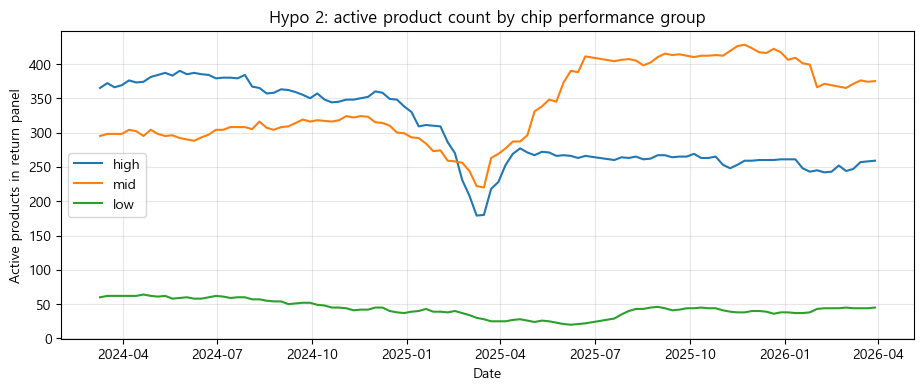

[saved plot] output_pic\hypo_2\Hypo_2_new_product_share_proxy_by_chip_performance_group.png


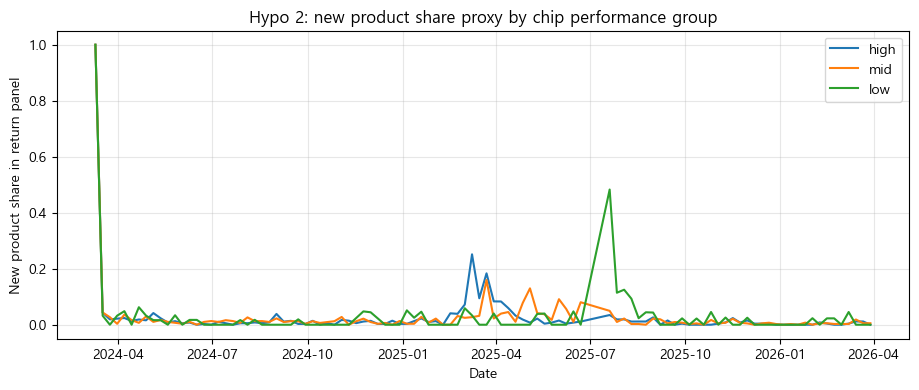

In [3]:
meta_g = gpu_meta[
    gpu_meta["chip_perf_group"].isin(GROUPS)
    & gpu_meta["h2_perf_group"].isin(GROUPS)
].copy()

vram_chip_n = (
    pd.crosstab(meta_g["chip_perf_group"], meta_g["h2_perf_group"])
      .reindex(index=GROUPS, columns=GROUPS, fill_value=0)
)
vram_chip_pct = vram_chip_n.div(vram_chip_n.sum(axis=1).replace(0, np.nan), axis=0)

vram_mis = pd.DataFrame([{
    "product_n": len(meta_g),
    "matched_chip_vram_group_n": int((meta_g["chip_perf_group"] == meta_g["h2_perf_group"]).sum()),
    "mismatched_chip_vram_group_n": int((meta_g["chip_perf_group"] != meta_g["h2_perf_group"]).sum()),
    "mismatch_rate": float((meta_g["chip_perf_group"] != meta_g["h2_perf_group"]).mean()),
}])

print("chip performance group × VRAM proxy group, count")
display(vram_chip_n)
print("chip performance group × VRAM proxy group, row percentage")
display(vram_chip_pct.round(3))
print("VRAM proxy mismatch summary")
display(vram_mis.round(4))

comp_panel = panel_gpu[panel_gpu["chip_perf_group"].isin(GROUPS)].copy()

first_w = (
    comp_panel.groupby(["row_id", "chip_perf_group"], as_index=False)["date"]
              .min()
              .rename(columns={"date": "date"})
)

active = (
    comp_panel.groupby(["date", "chip_perf_group"], as_index=False)["row_id"]
              .nunique()
              .rename(columns={"row_id": "active_product_n"})
)

new_prod = (
    first_w.groupby(["date", "chip_perf_group"], as_index=False)["row_id"]
              .nunique()
              .rename(columns={"row_id": "new_product_n"})
)

comp_diag = active.merge(new_prod, on=["date", "chip_perf_group"], how="left")
comp_diag["new_product_n"] = comp_diag["new_product_n"].fillna(0)
comp_diag["new_product_share"] = comp_diag["new_product_n"] / comp_diag["active_product_n"].replace(0, np.nan)
comp_diag["log_active_product_n"] = np.log1p(comp_diag["active_product_n"])

gap_c = gap_week.rename(columns={"group": "chip_perf_group"}).copy()
gap_c["bridge_ratio"] = gap_c["bridge_n"] / gap_c["adj_n"].replace(0, np.nan)

comp_diag = comp_diag.merge(
    gap_c[["date", "chip_perf_group", "adj_n", "bridge_n", "bridge_ratio"]],
    on=["date", "chip_perf_group"],
    how="left",
)

comp_sum = (
    comp_diag.groupby("chip_perf_group")
    .agg(
        mean_active_product_n=("active_product_n", "mean"),
        median_active_product_n=("active_product_n", "median"),
        max_new_product_share=("new_product_share", "max"),
        mean_new_product_share=("new_product_share", "mean"),
        max_bridge_ratio=("bridge_ratio", "max"),
        mean_bridge_ratio=("bridge_ratio", "mean"),
    )
    .reset_index()
)

print("product-composition diagnostic summary")
display(comp_sum.round(4))

plt.figure(figsize=(11, 4))
for g in GROUPS:
    sub = comp_diag[comp_diag["chip_perf_group"] == g]
    plt.plot(sub["date"], sub["active_product_n"], label=g)
plt.title("Hypo 2: active product count by chip performance group")
plt.xlabel("Date")
plt.ylabel("Active products in return panel")
plt.legend()
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

plt.figure(figsize=(11, 4))
for g in GROUPS:
    sub = comp_diag[comp_diag["chip_perf_group"] == g]
    plt.plot(sub["date"], sub["new_product_share"], label=g)
plt.title("Hypo 2: new product share proxy by chip performance group")
plt.xlabel("Date")
plt.ylabel("New product share in return panel")
plt.legend()
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

vram_chip_n.to_csv(H2_DIR / "vram_chip_n.csv")
vram_chip_pct.to_csv(H2_DIR / "vram_chip_pct.csv")
vram_mis.to_csv(H2_DIR / "vram_mismatch.csv", index=False)
comp_diag.to_csv(H2_DIR / "comp_diag.csv", index=False)
comp_sum.to_csv(H2_DIR / "comp_sum.csv", index=False)

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>1. 성능군별 가격지수와 주간 수익률 EDA</mark></b></span><br><br>

<b>[왜 이 과정을 하는가]</b><br>
회귀분석에 들어가기 전에 high/mid/low 가격지수가 서로 어떤 방향으로 움직였는지 확인한다. 가격지수 level은 설명용이고, 통계 검정은 주간 로그수익률을 사용한다.<br><br>

<b>[해석 기준]</b><br>
• index plot은 성능군별 누적 가격 흐름을 보여준다.<br>
• return plot은 BTC와 결합하기 전 각 성능군의 단기 변동성을 확인한다.<br>
• 특정 성능군만 극단적으로 변동하거나 장기간 결측이 많으면 이후 상호작용 회귀 결과를 해석할 때 주의한다.<br><br>

<b>[주의]</b><br>
가격지수 level이 같이 상승한다고 해서 BTC와의 관계를 바로 주장하면 안 된다. 추세로 인한 허위 상관을 피하기 위해 가설 검정은 <b>ret_chip_w의 주간 로그수익률</b>로 수행한다.
</div>

[saved plot] output_pic\hypo_2\Hypo_2_chip_performance_group_price_index.png


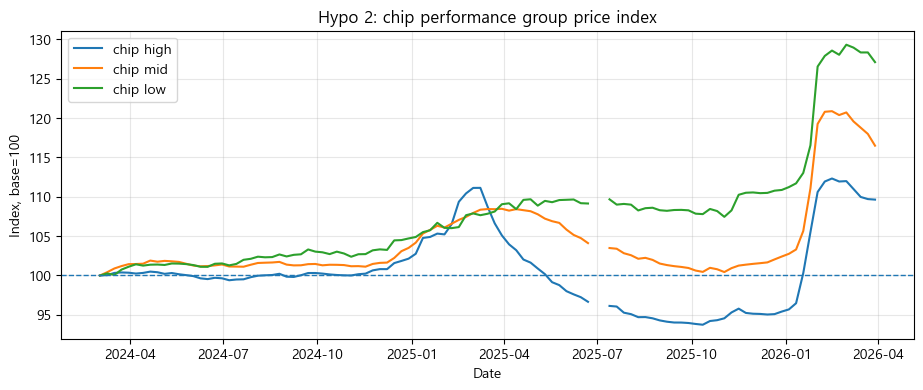

[saved plot] output_pic\hypo_2\Hypo_2_chip_performance_group_weekly_log_returns.png


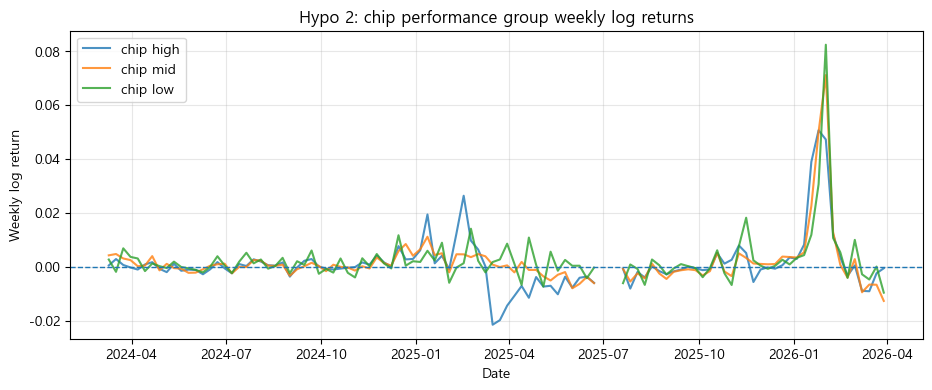

chip group return summary


,group,count,mean,std,min,median,max
0,high,105.0,0.00093,0.00991,-0.02155,-0.00028,0.05057
1,mid,105.0,0.00151,0.00950,-0.01272,0.00028,0.07104
2,low,105.0,0.00224,0.00955,-0.00965,0.00065,0.08230


In [4]:
chip_cols = [g for g in GROUPS if g in ret_chip_w.columns]
vram_cols = [g for g in GROUPS if g in ret_vram_w.columns]

plt.figure(figsize=(11, 4))
for g in chip_cols:
    plt.plot(idx_chip_w.index, idx_chip_w[g], label=f"chip {g}")
plt.axhline(100, linestyle="--", linewidth=1)
plt.title("Hypo 2: chip performance group price index")
plt.xlabel("Date")
plt.ylabel("Index, base=100")
plt.legend()
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

plt.figure(figsize=(11, 4))
for g in chip_cols:
    plt.plot(ret_chip_w.index, ret_chip_w[g], label=f"chip {g}", alpha=0.8)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Hypo 2: chip performance group weekly log returns")
plt.xlabel("Date")
plt.ylabel("Weekly log return")
plt.legend()
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

chip_ret = (
    ret_chip_w[chip_cols]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .T
    .reset_index()
    .rename(columns={"index": "group"})
)

print("chip group return summary")
display(chip_ret.round(5))
chip_ret.to_csv(H2_DIR / "chip_ret.csv", index=False)

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>2. Phase 1: One-way ANOVA / Welch ANOVA 탐색 분석</mark></b></span><br><br>

<b>[왜 이 기법을 쓰는가]</b><br>
슬라이드의 Phase 1은 성능군별 평균 반응도가 다르게 나타나는지 먼저 탐색하는 단계이다. 따라서 high/mid/low의 주간 로그수익률 평균이 서로 다른지 One-way ANOVA로 확인한다.<br><br>

<b>[Levene 검정과 Welch ANOVA]</b><br>
성능군별 수익률 분산이 같다는 보장이 없으므로 먼저 Levene 검정으로 등분산성을 확인한다. 등분산성이 약하면 일반 ANOVA보다 <b>Welch ANOVA</b>를 우선 참고한다.<br><br>

<b>[중요한 한계]</b><br>
이 ANOVA는 BTC 변동, 환율, NVDA 수익률을 통제하지 않는다. 또한 동일 주차의 high/mid/low 수익률은 공통 시장 충격을 공유한다. 따라서 이 단계는 최종 가설 검정이 아니라 <b>탐색적 차이 확인</b>으로만 사용한다.<br><br>

<b>[실행 후 해석]</b><br>
ANOVA p-value가 유의하면 성능군별 평균 변동률 자체가 다를 수 있다는 신호이다. 그러나 Hypo 2의 핵심은 평균 차이가 아니라 <b>BTC에 대한 민감도 차이</b>이므로 최종 결론은 다음 상호작용 회귀에서 판단한다.
</div>

ANOVA / Welch ANOVA results


,block,test,stat,p_value,note
0,chip_main,Levene_median,0.39014,0.67729,H0: equal variances
1,chip_main,One_way_ANOVA,0.48481,0.61627,H0: equal group means
2,chip_main,Welch_ANOVA,0.47715,0.62123,"H0: equal group means, unequal variance allowed"
3,vram_proxy,Levene_median,5.68271,0.00377,H0: equal variances
4,vram_proxy,One_way_ANOVA,0.25420,0.77569,H0: equal group means
5,vram_proxy,Welch_ANOVA,0.33437,0.71628,"H0: equal group means, unequal variance allowed"


[saved plot] output_pic\hypo_2\Hypo_2_Phase_1_chip_group_weekly_returns_02.png


<Figure size 800x400 with 0 Axes>

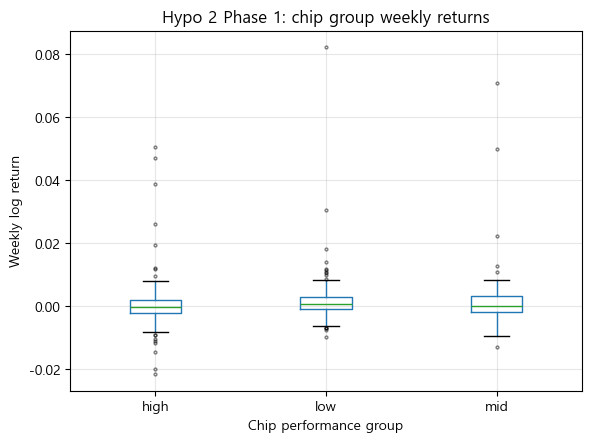

In [6]:
def run_anova(ret_w, cols, block_name):
    samples = [ret_w[g].dropna().to_numpy(float) for g in cols]
    labels = cols

    levene_stat, levene_p = stats.levene(*samples, center="median")
    f_stat, f_p = stats.f_oneway(*samples)
    welch = anova_oneway(samples, use_var="unequal")

    out = pd.DataFrame([
        {"block": block_name, "test": "Levene_median", "stat": levene_stat, "p_value": levene_p, "note": "H0: equal variances"},
        {"block": block_name, "test": "One_way_ANOVA", "stat": f_stat, "p_value": f_p, "note": "H0: equal group means"},
        {"block": block_name, "test": "Welch_ANOVA", "stat": welch.statistic, "p_value": welch.pvalue, "note": "H0: equal group means, unequal variance allowed"},
    ])

    long = (
        ret_w[cols]
        .reset_index()
        .melt(id_vars="date", value_vars=cols, var_name="group", value_name="gpu_ret")
        .dropna()
    )

    return out, long

anova_chip, chip_long_anova = run_anova(ret_chip_w, chip_cols, "chip_main")
anova_vram, vram_long_anova = run_anova(ret_vram_w, vram_cols, "vram_proxy")
anova_results = pd.concat([anova_chip, anova_vram], ignore_index=True)

print("ANOVA / Welch ANOVA results")
display(anova_results.round(5))
anova_results.to_csv(H2_DIR / "anova.csv", index=False)

plt.figure(figsize=(8, 4))
chip_long_anova.boxplot(column="gpu_ret", by="group", flierprops={
        "marker": "o",
        "markersize": 2,
        "alpha": 0.5,
    })
plt.title("Hypo 2 Phase 1: chip group weekly returns")
plt.suptitle("")
plt.xlabel("Chip performance group")
plt.ylabel("Weekly log return")
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>3. Phase 2 데이터셋 구성: BTC × 성능군 상호작용</mark></b></span><br><br>

<b>[왜 long-form panel로 바꾸는가]</b><br>
Hypo 2는 high, mid, low 세 개의 수익률 시계열을 비교하는 문제이다. 따라서 wide-form을 <b>date / group / gpu_ret</b> 형태로 바꿔야 성능군 dummy와 BTC 수익률의 상호작용항을 만들 수 있다.<br><br>

<b>[기준항 변경]</b><br>
기존 low 기준 회귀는 low 그룹의 제품 수와 매칭 수가 작아 기준항 자체의 노이즈가 클 수 있다. 따라서 본모형은 <b>mid 그룹을 기준항</b>으로 두고, high와 low의 추가 민감도를 각각 mid와 비교한다. high-vs-low 차이는 회귀식의 선형 contrast로 별도 검정한다.<br><br>

<b>[핵심 변수]</b><br>
• <b>btc_krw_ret_l0 ~ btc_krw_ret_l8</b>: BTC 변동이 즉시 또는 지연되어 성능군별 GPU 가격에 반영되는지 확인한다.<br>
• <b>high_btc_lk</b>: k주 lag BTC 수익률에 대한 high 그룹의 추가 민감도이다. mid 그룹이 기준이다.<br>
• <b>low_btc_lk</b>: k주 lag BTC 수익률에 대한 low 그룹의 추가 민감도이다. mid 그룹이 기준이다.<br>
• <b>high_nvda_ret, low_nvda_ret</b>: AI/반도체 수요가 성능군별로 다르게 작용할 수 있으므로 추가 통제한다.<br>
• <b>gpu_ret_l1</b>: 각 성능군 가격 수익률의 자기시차를 통제한다.<br>
• <b>composition controls</b>: 제품 진입/활성 제품 수/bridge gap 비율은 본모형에는 바로 넣지 않고, 신제품·표본구성 효과를 점검하는 강건성 분석에서 추가한다.<br><br>

<b>[해석 기준]</b><br>
• high_btc 계수들이 양수이고 공동으로 유의하면 high GPU가 mid GPU보다 BTC 변화에 더 민감하다는 근거가 된다.<br>
• high-low 차이는 high_btc와 low_btc의 차이에 대한 contrast로 확인한다.
</div>

In [7]:
def make_reg_df(ret_w, block_name, cols):
    long = (
        ret_w[cols]
        .reset_index()
        .melt(id_vars="date", value_vars=cols, var_name="group", value_name="gpu_ret")
        .dropna(subset=["gpu_ret"])
        .sort_values(["group", "date"])
        .copy()
    )

    dat = long.merge(mkt.reset_index().rename(columns={mkt.index.name or "index": "date"}), on="date", how="inner")
    dat = dat.sort_values(["group", "date"]).copy()

    dat["gpu_ret_l1"] = dat.groupby("group")["gpu_ret"].shift(1)

    dat["is_high"] = (dat["group"] == "high").astype(int)
    dat["is_low"] = (dat["group"] == "low").astype(int)

    btc_lags = [f"btc_krw_ret_l{k}" for k in range(L + 1)]
    for col in btc_lags:
        lag = col.replace("btc_krw_ret_l", "")
        dat[f"high_btc_l{lag}"] = dat["is_high"] * dat[col]
        dat[f"low_btc_l{lag}"] = dat["is_low"] * dat[col]

    dat["high_nvda_ret"] = dat["is_high"] * dat["nvda_ret"]
    dat["low_nvda_ret"] = dat["is_low"] * dat["nvda_ret"]
    dat["high_fx_ret"] = dat["is_high"] * dat["fx_ret"]
    dat["low_fx_ret"] = dat["is_low"] * dat["fx_ret"]

    dat["block"] = block_name
    return dat

h2_chip = make_reg_df(ret_chip_w, "chip_main", chip_cols)
h2_vram = make_reg_df(ret_vram_w, "vram_proxy", vram_cols)

btc_lags = [f"btc_krw_ret_l{k}" for k in range(L + 1)]
hi_btc = [f"high_btc_l{k}" for k in range(L + 1)]
low_btc = [f"low_btc_l{k}" for k in range(L + 1)]

model_cols = (
    ["gpu_ret", "date", "group", "is_high", "is_low"]
    + btc_lags
    + hi_btc
    + low_btc
    + ["fx_ret", "nvda_ret", "high_fx_ret", "low_fx_ret", "high_nvda_ret", "low_nvda_ret", "gpu_ret_l1"]
)

chip_reg = h2_chip[model_cols].dropna().copy()
vram_reg = h2_vram[model_cols].dropna().copy()

print("H2 chip regression dataset, mid as base group")
display(chip_reg.head())
print("H2 VRAM proxy regression dataset, mid as base group")
display(vram_reg.head())

sample_check = pd.DataFrame([
    {"block": "chip_main", "base_group": BASE, "raw_rows": len(h2_chip), "complete_reg_rows": len(chip_reg), "week_n": chip_reg["date"].nunique()},
    {"block": "vram_proxy", "base_group": BASE, "raw_rows": len(h2_vram), "complete_reg_rows": len(vram_reg), "week_n": vram_reg["date"].nunique()},
])

print("H2 sample check")
display(sample_check)

h2_chip.to_csv(H2_DIR / "chip_raw.csv", index=False)
chip_reg.to_csv(H2_DIR / "chip_reg.csv", index=False)
h2_vram.to_csv(H2_DIR / "vram_raw.csv", index=False)
vram_reg.to_csv(H2_DIR / "vram_reg.csv", index=False)
sample_check.to_csv(H2_DIR / "sample.csv", index=False)

H2 chip regression dataset, mid as base group


,gpu_ret,date,group,is_high,is_low,btc_krw_ret_l0,btc_krw_ret_l1,btc_krw_ret_l2,btc_krw_ret_l3,btc_krw_ret_l4,...,low_btc_l6,low_btc_l7,low_btc_l8,fx_ret,nvda_ret,high_fx_ret,low_fx_ret,high_nvda_ret,low_nvda_ret,gpu_ret_l1
8,-0.002043,2024-05-05,high,1,0,-0.051308,0.011898,-0.061172,0.017280,-0.028035,...,-0.0,0.0,0.0,0.000705,0.047370,0.000705,0.0,0.047370,0.0,-0.000792
9,0.001045,2024-05-12,high,1,0,-0.001375,-0.051308,0.011898,-0.061172,0.017280,...,0.0,-0.0,0.0,-0.012364,0.045296,-0.012364,-0.0,0.045296,0.0,-0.002043
10,-0.001546,2024-05-19,high,1,0,0.046114,-0.001375,-0.051308,0.011898,-0.061172,...,-0.0,0.0,-0.0,0.000546,0.025037,0.000546,0.0,0.025037,0.0,0.001045
11,-0.001123,2024-05-26,high,1,0,0.068650,0.046114,-0.001375,-0.051308,0.011898,...,0.0,-0.0,0.0,0.002116,0.066018,0.002116,0.0,0.066018,0.0,-0.001546
12,-0.001235,2024-06-02,high,1,0,-0.010918,0.068650,0.046114,-0.001375,-0.051308,...,-0.0,0.0,-0.0,0.003688,0.125593,0.003688,0.0,0.125593,0.0,-0.001123


H2 VRAM proxy regression dataset, mid as base group


,gpu_ret,date,group,is_high,is_low,btc_krw_ret_l0,btc_krw_ret_l1,btc_krw_ret_l2,btc_krw_ret_l3,btc_krw_ret_l4,...,low_btc_l6,low_btc_l7,low_btc_l8,fx_ret,nvda_ret,high_fx_ret,low_fx_ret,high_nvda_ret,low_nvda_ret,gpu_ret_l1
8,-0.001819,2024-05-05,high,1,0,-0.051308,0.011898,-0.061172,0.017280,-0.028035,...,-0.0,0.0,0.0,0.000705,0.047370,0.000705,0.0,0.047370,0.0,-0.001028
9,0.001052,2024-05-12,high,1,0,-0.001375,-0.051308,0.011898,-0.061172,0.017280,...,0.0,-0.0,0.0,-0.012364,0.045296,-0.012364,-0.0,0.045296,0.0,-0.001819
10,-0.001710,2024-05-19,high,1,0,0.046114,-0.001375,-0.051308,0.011898,-0.061172,...,-0.0,0.0,-0.0,0.000546,0.025037,0.000546,0.0,0.025037,0.0,0.001052
11,-0.001190,2024-05-26,high,1,0,0.068650,0.046114,-0.001375,-0.051308,0.011898,...,0.0,-0.0,0.0,0.002116,0.066018,0.002116,0.0,0.066018,0.0,-0.001710
12,-0.001754,2024-06-02,high,1,0,-0.010918,0.068650,0.046114,-0.001375,-0.051308,...,-0.0,0.0,-0.0,0.003688,0.125593,0.003688,0.0,0.125593,0.0,-0.001190


H2 sample check


,block,base_group,raw_rows,complete_reg_rows,week_n
0,chip_main,mid,315,291,97
1,vram_proxy,mid,315,291,97


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>3-0. BTC-GPU 수익률 산점도: 성능군별 민감도 시각화</mark></b></span><br><br>
<b>[왜 추가하는가]</b><br>
상호작용 회귀 전에 BTC 수익률과 성능군별 GPU 수익률의 관계를 산점도와 단순 추세선으로 확인한다. ANOVA는 그룹 평균 차이만 보여주므로, BTC 변화에 대한 기울기 차이는 별도 시각화가 필요하다.<br><br>
<b>[해석 기준]</b><br>
각 성능군의 추세선 기울기가 BTC 민감도의 시각적 proxy이다. 다만 산점도는 통제변수를 반영하지 않은 EDA이므로, 최종 판단은 BTC × 성능군 상호작용 회귀와 공동 유의성 검정으로 한다.
</div>

[saved plot] output_pic\hypo_2\BTC-KRW_return_vs_GPU_return_by_chip_performance_group.png


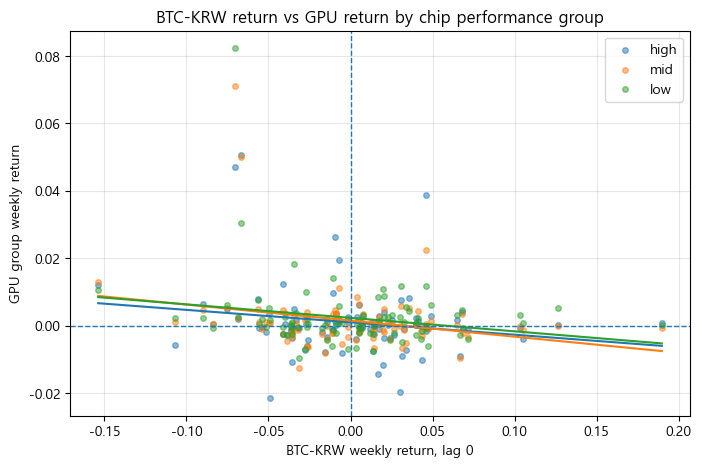

Group-wise scatter trend summary


,group,n,corr_l0,simple_beta_l0,simple_beta_p,intercept
0,high,97,-0.17787,-0.03683,0.08134,0.00098
1,mid,97,-0.24024,-0.04762,0.01777,0.00148
2,low,97,-0.20081,-0.03999,0.04859,0.00230


In [8]:
scatter_rows = []
scatter_df = chip_reg[["date", "group", "gpu_ret", "btc_krw_ret_l0"]].dropna().copy()

plt.figure(figsize=(8, 5))
for g in GROUPS:
    sub = scatter_df[scatter_df["group"] == g].copy()
    if sub.empty:
        continue
    x = sub["btc_krw_ret_l0"].to_numpy(float)
    y = sub["gpu_ret"].to_numpy(float)
    plt.scatter(x, y, s=16, alpha=0.5, label=g)

    if len(sub) >= 8 and np.nanvar(x) > 0:
        slope, intercept = np.polyfit(x, y, 1)
        x_line = np.linspace(np.nanmin(x), np.nanmax(x), 50)
        y_line = intercept + slope * x_line
        plt.plot(x_line, y_line, linewidth=1.5)
        corr = sub["gpu_ret"].corr(sub["btc_krw_ret_l0"])
        simple_mod = smf.ols("gpu_ret ~ btc_krw_ret_l0", data=sub).fit()
        scatter_rows.append({
            "group": g,
            "n": len(sub),
            "corr_l0": corr,
            "simple_beta_l0": simple_mod.params.get("btc_krw_ret_l0", np.nan),
            "simple_beta_p": simple_mod.pvalues.get("btc_krw_ret_l0", np.nan),
            "intercept": simple_mod.params.get("Intercept", np.nan),
        })

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("BTC-KRW return vs GPU return by chip performance group")
plt.xlabel("BTC-KRW weekly return, lag 0")
plt.ylabel("GPU group weekly return")
plt.legend()
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

scatter_summary = pd.DataFrame(scatter_rows)
print("Group-wise scatter trend summary")
display(scatter_summary.round(5))
scatter_summary.to_csv(H2_DIR / "scatter_beta.csv", index=False)

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>3-0-1. 성능군별 CCF: BTC lag 반응 시각화</mark></b></span><br><br>
<b>[왜 추가하는가]</b><br>
전체 GPU 지수의 CCF만 보면 Hypo 2의 핵심인 high/mid/low 반응 차이를 볼 수 없다. 따라서 성능군별로 GPU 수익률과 BTC lag 수익률의 상관을 따로 계산하고, 95% 근사 confidence band를 함께 표시한다.<br><br>
<b>[해석 기준]</b><br>
특정 그룹에서만 band 밖으로 나가는 lag가 반복적으로 나타나면 민감도 차이의 시각적 근거가 될 수 있다. 다만 표본 수가 100주 내외이므로 CCF는 본검정이 아니라 상호작용 회귀 전 EDA로만 사용한다.
</div>

Group-specific CCF table


,group,lag_week,corr,n,approx_95_band,outside_band
0,high,0,-0.1779,97,0.199,False
1,high,1,-0.0398,97,0.199,False
2,high,2,0.0948,97,0.199,False
3,high,3,0.0839,97,0.199,False
4,high,4,0.1138,97,0.199,False
5,high,5,0.1103,97,0.199,False
6,high,6,0.0423,97,0.199,False
7,high,7,0.0548,97,0.199,False
8,high,8,0.0289,97,0.199,False
9,mid,0,-0.2402,97,0.199,True


[saved plot] output_pic\hypo_2\Hypo_2_EDA_group-specific_CCF_with_approximate_95%_band.png


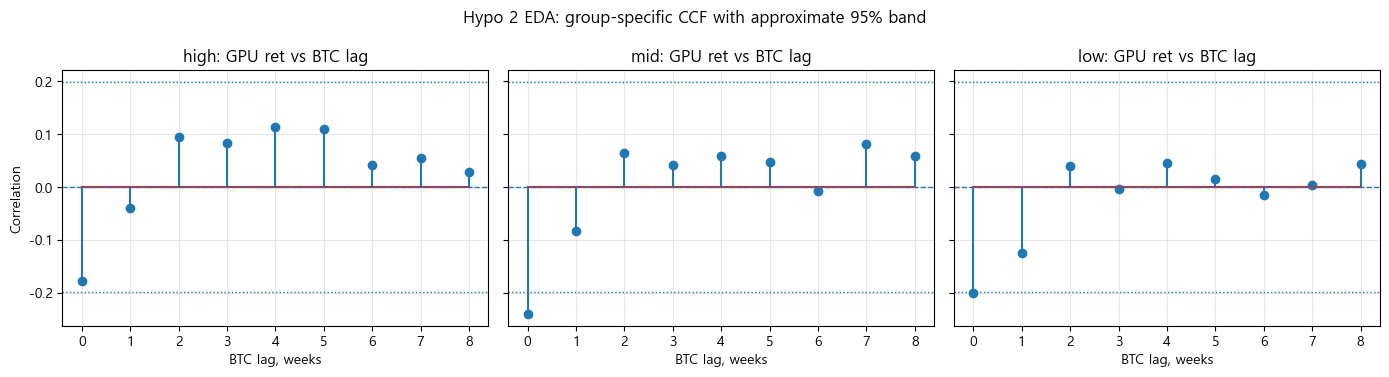

In [9]:
ccf_rows = []
for g in GROUPS:
    sub = chip_reg[chip_reg["group"] == g].copy()
    for k in range(L + 1):
        col = f"btc_krw_ret_l{k}"
        tmp = sub[["gpu_ret", col]].dropna()
        if len(tmp) == 0:
            corr = np.nan
            band = np.nan
        else:
            corr = tmp["gpu_ret"].corr(tmp[col])
            band = 1.96 / np.sqrt(len(tmp))
        ccf_rows.append({
            "group": g,
            "lag_week": k,
            "corr": corr,
            "n": len(tmp),
            "approx_95_band": band,
            "outside_band": bool(abs(corr) > band) if pd.notna(corr) and pd.notna(band) else False,
        })

ccf_group = pd.DataFrame(ccf_rows)
print("Group-specific CCF table")
display(ccf_group.round(4))
ccf_group.to_csv(H2_DIR / "ccf_group.csv", index=False)

fig, axes = plt.subplots(1, len(GROUPS), figsize=(14, 3.8), sharey=True)
for ax, g in zip(axes, GROUPS):
    sub = ccf_group[ccf_group["group"] == g].sort_values("lag_week")
    ax.stem(sub["lag_week"], sub["corr"])
    band = sub["approx_95_band"].median()
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.axhline(band, linestyle=":", linewidth=1)
    ax.axhline(-band, linestyle=":", linewidth=1)
    ax.set_title(f"{g}: GPU ret vs BTC lag")
    ax.set_xlabel("BTC lag, weeks")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Correlation")
plt.suptitle("Hypo 2 EDA: group-specific CCF with approximate 95% band")
plt.tight_layout()
save_plot(); plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>3-0-2. 변동성 군집 EDA: HAC/cluster 표준오차의 필요성 점검</mark></b></span><br><br>
<b>[왜 추가하는가]</b><br>
GPU와 BTC 수익률이 특정 기간에 함께 크게 흔들리면 잔차의 분산이 일정하다는 가정이 약해진다. 따라서 성능군별 squared return과 rolling standard deviation을 확인하여 변동성 군집 가능성을 본다.<br><br>
<b>[해석 기준]</b><br>
변동성 군집이 보이면 일반 OLS 표준오차보다 cluster-robust 또는 HAC 계열 표준오차를 쓰는 것이 더 타당하다. 이 분석은 표준오차 선택의 정당성을 보여주는 EDA이다.
</div>

Group volatility clustering summary


,group,n,mean_sq_ret,max_sq_ret,corr_sqret_absbtc,corr_rollstd12_absbtc,corr_rollstd24_absbtc
0,high,97,0.00011,0.00256,0.11893,0.09134,0.04453
1,low,97,0.00010,0.00677,0.11620,0.10544,0.13482
2,mid,97,0.00010,0.00505,0.14112,0.11631,0.14296


[saved plot] output_pic\hypo_2\Hypo_2_EDA_chip_group_rolling_volatility.png


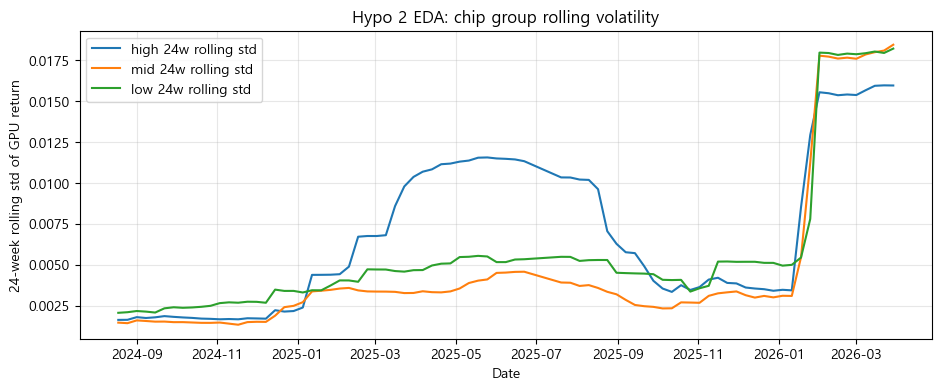

In [10]:
vol_df = chip_reg[["date", "group", "gpu_ret", "btc_krw_ret_l0"]].dropna().copy().sort_values(["group", "date"])
vol_df["gpu_ret_sq"] = vol_df["gpu_ret"] ** 2
vol_df["btc_ret_abs"] = vol_df["btc_krw_ret_l0"].abs()
vol_df["gpu_roll_std_12w"] = vol_df.groupby("group")["gpu_ret"].transform(lambda s: s.rolling(12, min_periods=8).std())
vol_df["gpu_roll_std_24w"] = vol_df.groupby("group")["gpu_ret"].transform(lambda s: s.rolling(24, min_periods=16).std())

vol_rows = []
for g, sub in vol_df.groupby("group"):
    vol_rows.append({
        "group": g,
        "n": len(sub),
        "mean_sq_ret": sub["gpu_ret_sq"].mean(),
        "max_sq_ret": sub["gpu_ret_sq"].max(),
        "corr_sqret_absbtc": sub["gpu_ret_sq"].corr(sub["btc_ret_abs"]),
        "corr_rollstd12_absbtc": sub["gpu_roll_std_12w"].corr(sub["btc_ret_abs"]),
        "corr_rollstd24_absbtc": sub["gpu_roll_std_24w"].corr(sub["btc_ret_abs"]),
    })
vol_summary = pd.DataFrame(vol_rows)
print("Group volatility clustering summary")
display(vol_summary.round(5))
vol_df.to_csv(H2_DIR / "vol_group.csv", index=False)
vol_summary.to_csv(H2_DIR / "vol_sum.csv", index=False)

plt.figure(figsize=(11, 4))
for g in GROUPS:
    sub = vol_df[vol_df["group"] == g]
    plt.plot(sub["date"], sub["gpu_roll_std_24w"], label=f"{g} 24w rolling std")
plt.title("Hypo 2 EDA: chip group rolling volatility")
plt.xlabel("Date")
plt.ylabel("24-week rolling std of GPU return")
plt.legend()
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>3-1. Regime EDA: 성능군별 민감도의 기간 변화</mark></b></span><br><br>
<b>[왜 추가하는가]</b><br>
고성능 GPU 민감도는 전체 기간에서 일정하지 않고 특정 시장 국면에서만 나타날 수 있다. 명확한 외부 이벤트 날짜를 임의로 지정하지 않고, 데이터 내부 기준으로 early/late 기간과 BTC 고변동/저변동 regime을 나누어 성능군별 단순 beta가 달라지는지 확인한다.<br><br>
<b>[해석 기준]</b><br>
이 분석은 구조적 변화 가능성을 보는 EDA이다. 사후 구간 분할이므로 결론을 확정하지 않고, 메인 상호작용 회귀 결과를 보완하는 용도로만 사용한다.
</div>

In [11]:
reg2 = chip_reg[["date", "group", "gpu_ret", "btc_krw_ret_l0"]].dropna().copy().sort_values("date")
unique_dates = sorted(reg2["date"].unique())
mid_date = unique_dates[len(unique_dates)//2]
reg2["time_regime"] = np.where(reg2["date"] < mid_date, "early", "late")

btc_date = (
    chip_reg[["date", "btc_krw_ret_l0"]]
    .drop_duplicates("date")
    .sort_values("date")
    .set_index("date")
)
btc_date["btc_vol_12w"] = btc_date["btc_krw_ret_l0"].rolling(12, min_periods=12).std()
vol_cut = btc_date["btc_vol_12w"].median()
btc_date["btc_vol_regime"] = np.where(btc_date["btc_vol_12w"] >= vol_cut, "high_btc_vol", "low_btc_vol")
btc_date.loc[btc_date["btc_vol_12w"].isna(), "btc_vol_regime"] = np.nan
reg2 = reg2.merge(btc_date[["btc_vol_regime"]].reset_index(), on="date", how="left")


def group_regime_beta(df, regime_col):
    rows = []
    for (regime, group), sub in df.dropna(subset=[regime_col]).groupby([regime_col, "group"]):
        if len(sub) < 8 or sub["btc_krw_ret_l0"].var() == 0:
            continue
        beta = sub["gpu_ret"].cov(sub["btc_krw_ret_l0"]) / sub["btc_krw_ret_l0"].var()
        rows.append({
            "regime_type": regime_col,
            "regime": regime,
            "group": group,
            "n": len(sub),
            "corr_l0": sub["gpu_ret"].corr(sub["btc_krw_ret_l0"]),
            "simple_beta_l0": beta,
        })
    return pd.DataFrame(rows)

h2_regime_beta = pd.concat([
    group_regime_beta(reg2, "time_regime"),
    group_regime_beta(reg2, "btc_vol_regime"),
], ignore_index=True)

print("H2 group beta by regime")
display(h2_regime_beta.round(5))
reg2.to_csv(H2_DIR / "regime.csv", index=False)
h2_regime_beta.to_csv(H2_DIR / "regime_beta.csv", index=False)

H2 group beta by regime


,regime_type,regime,group,n,corr_l0,simple_beta_l0
0,time_regime,early,high,48,-0.03009,-0.00422
1,time_regime,early,low,48,0.13004,0.00933
2,time_regime,early,mid,48,-0.11718,-0.00648
3,time_regime,late,high,49,-0.29522,-0.08084
4,time_regime,late,low,49,-0.34578,-0.10128
5,time_regime,late,mid,49,-0.34520,-0.10250
6,btc_vol_regime,high_btc_vol,high,43,-0.20351,-0.01760
7,btc_vol_regime,high_btc_vol,low,43,-0.07130,-0.00528
8,btc_vol_regime,high_btc_vol,mid,43,-0.23181,-0.01830
9,btc_vol_regime,low_btc_vol,high,43,-0.24035,-0.09263


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>3-1. Lag 변수 결측 전파 및 표본 손실 점검</mark></b></span><br><br>
<b>[왜 추가하는가]</b><br>
BTC lag 0~8주와 성능군별 자기시차를 동시에 만들면 앞쪽 주차가 구조적으로 제외되고, 특정 성능군의 ret_w 결측도 회귀 표본에서 빠진다. lag 변수는 forward fill하지 않고 실제 관측된 주간 수익률만 사용해야 하므로, 회귀 투입 전 complete-case 표본이 얼마나 남는지 확인한다.<br><br>
<b>[해석 기준]</b><br>
이 표는 H2의 유의성 부족이 단순히 과도한 결측 처리 때문인지 점검하기 위한 진단이다.
</div>

In [12]:
def h2_lag_audit(raw_df, reg_df, block):
    rows = []
    for group, sub in raw_df.groupby("group"):
        rows.append({
            "block": block,
            "group": group,
            "raw_rows": len(sub),
            "gpu_ret_nonnull": int(sub["gpu_ret"].notna().sum()),
            "btc_lag0_nonnull": int(sub["btc_krw_ret_l0"].notna().sum()),
            f"btc_lag{L}_nonnull": int(sub[f"btc_krw_ret_l{L}"].notna().sum()),
            "gpu_ret_l1_nonnull": int(sub["gpu_ret_l1"].notna().sum()),
            "complete_reg_rows": int(reg_df[reg_df["group"] == group].shape[0]),
            "dropped_rows": int(len(sub) - reg_df[reg_df["group"] == group].shape[0]),
            "ffill_used": False,
        })
    return pd.DataFrame(rows)


lag_audit = pd.concat(
    [
        h2_lag_audit(h2_chip, chip_reg, "chip_main"),
        h2_lag_audit(h2_vram, vram_reg, "vram_proxy"),
    ],
    ignore_index=True,
)

print("H2 lag missingness audit")
display(lag_audit)

lag_audit.to_csv(H2_DIR / "lag_na.csv", index=False)

H2 lag missingness audit


,block,group,raw_rows,gpu_ret_nonnull,btc_lag0_nonnull,btc_lag8_nonnull,gpu_ret_l1_nonnull,complete_reg_rows,dropped_rows,ffill_used
0,chip_main,high,105,105,105,97,104,97,8,False
1,chip_main,low,105,105,105,97,104,97,8,False
2,chip_main,mid,105,105,105,97,104,97,8,False
3,vram_proxy,high,105,105,105,97,104,97,8,False
4,vram_proxy,low,105,105,105,97,104,97,8,False
5,vram_proxy,mid,105,105,105,97,104,97,8,False


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>4. H2 메인 검정: 성능군별 BTC 민감도 차이</mark></b></span><br><br>

<b>[모형 구조]</b><br>
종속변수는 성능군별 주간 GPU 로그수익률이다. 설명변수에는 BTC lag 0~8주, high/mid 성능군 dummy, 그리고 BTC lag × high/mid 상호작용을 넣는다. 기준 그룹은 low이다.<br><br>

<b>[왜 이 회귀가 Hypo 2의 본 검정인가]</b><br>
가설 2는 “high GPU 가격이 더 올랐다”가 아니라 “BTC 변화에 대한 high GPU의 반응계수가 더 크다”는 주장이다. 따라서 평균 비교가 아니라 <b>BTC × 성능군 상호작용항</b>이 직접 검정 대상이다.<br><br>

<b>[통제변수]</b><br>
• <b>fx_ret</b>: 원화 가격에 반영되는 환율 효과 통제<br>
• <b>nvda_ret</b>: AI/반도체 수요 proxy 통제<br>
• <b>NVDA × 성능군</b>: AI 수요가 고성능 GPU에 더 강하게 작용할 수 있음을 통제<br>
• <b>gpu_ret_l1</b>: 성능군별 가격 수익률의 단기 관성 통제<br><br>

<b>[표준오차]</b><br>
같은 주차의 high/mid/low 수익률은 공통 시장 충격을 공유하므로, 표준오차는 <b>date 기준 cluster-robust</b>로 계산한다.<br><br>

<b>[실행 후 해석]</b><br>
• <b>high_btc_l0 ~ high_btc_l8 공동 유의성</b>: high 그룹이 low 그룹보다 BTC에 다르게 반응하는지 확인<br>
• <b>cumulative high-low effect</b>: 0~8주 전체 BTC 반응의 누적 차이가 양수인지 확인<br>
• 이 값이 양수이고 유의하면 Hypo 2를 지지하는 핵심 근거가 된다.<br>
• BTC lag를 0~8주까지 모두 넣었기 때문에 개별 lag 계수의 p-value만으로 결론을 내리면 안 된다. 본문에서는 <b>공동 유의성 검정</b>과 <b>0~8주 누적 효과</b>를 최종 판단 기준으로 둔다.<br>
• 정확한 출시일 더미가 없으므로 신제품 효과는 본모형의 한계로 남긴다. 대신 뒤에서 제품구성 proxy를 통제하는 강건성 분석을 별도로 수행한다.
</div>

In [13]:
x_cols = (
    ["is_high", "is_low"]
    + btc_lags
    + hi_btc
    + low_btc
    + ["fx_ret", "nvda_ret", "high_fx_ret", "low_fx_ret", "high_nvda_ret", "low_nvda_ret", "gpu_ret_l1"]
)


def fit_int(dat, block_name):
    y = dat["gpu_ret"].astype(float)
    X = sm.add_constant(dat[x_cols].astype(float), has_constant="add")

    model = sm.OLS(y, X).fit(
        cov_type="cluster",
        cov_kwds={"groups": dat["date"]}
    )

    coef = pd.DataFrame({
        "term": model.params.index,
        "coef": model.params.values,
        "se": model.bse.values,
        "t": model.tvalues.values,
        "p_value": model.pvalues.values,
        "block": block_name,
        "base_group": BASE,
    })
    return model, coef


chip_mod, chip_coef = fit_int(chip_reg, "chip_main")
vram_mod, vram_coef = fit_int(vram_reg, "vram_proxy")

print(chip_mod.summary())
print("chip main coefficient table")
display(chip_coef.round(5))

chip_coef.to_csv(H2_DIR / "chip_coef.csv", index=False)
vram_coef.to_csv(H2_DIR / "vram_coef.csv", index=False)

                            OLS Regression Results                            
Dep. Variable:                gpu_ret   R-squared:                       0.442
Model:                            OLS   Adj. R-squared:                  0.363
Method:                 Least Squares   F-statistic:                     3.435
Date:                Mon, 04 May 2026   Prob (F-statistic):           8.05e-07
Time:                        14:11:42   Log-Likelihood:                 1012.3
No. Observations:                 291   AIC:                            -1951.
Df Residuals:                     254   BIC:                            -1815.
Df Model:                          36                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0003      0.000      0.

,term,coef,se,t,p_value,block,base_group
0,const,0.00034,0.00049,0.68718,0.49197,chip_main,mid
1,is_high,-0.00018,0.00049,-0.36876,0.71231,chip_main,mid
2,is_low,0.00045,0.00056,0.80266,0.42217,chip_main,mid
3,btc_krw_ret_l0,-0.01353,0.01793,-0.75470,0.45043,chip_main,mid
4,btc_krw_ret_l1,0.01892,0.01813,1.04342,0.29676,chip_main,mid
5,btc_krw_ret_l2,0.02999,0.02089,1.43574,0.15108,chip_main,mid
6,btc_krw_ret_l3,-0.01718,0.00939,-1.82855,0.06747,chip_main,mid
7,btc_krw_ret_l4,0.00283,0.01446,0.19545,0.84504,chip_main,mid
8,btc_krw_ret_l5,0.00573,0.01172,0.48867,0.62507,chip_main,mid
9,btc_krw_ret_l6,-0.02388,0.01285,-1.85848,0.06310,chip_main,mid


<div style="line-height: 1.8;">
<br>
<span style="font-size: 20px;"><b><mark>4-1. Main Regression Residual Plot / Q-Q Plot</mark></b></span><br><br>
<b>[왜 추가하는가]</b><br>
cluster-robust 표준오차를 사용하더라도, 잔차가 특정 주간에 집중적으로 튀거나 fat-tail을 보이면 미통제 시장 국면이 남아 있을 수 있다. 따라서 chip 기준 본모형의 잔차를 날짜별 평균으로 집계해 시계열 plot을 그리고, 전체 잔차의 Q-Q plot을 확인한다.<br><br>
<b>[해석]</b><br>
잔차 spike는 신제품 출시, 재고/품절, 기술주 이벤트, 유통망 충격 등이 모형에 완전히 반영되지 않았을 가능성을 의미한다. Q-Q plot 양끝이 크게 벗어나면 개별 계수보다 공동검정과 강건성 분석을 중심으로 결론을 내리는 것이 타당하다.<br><br>
</div>

H2 main residual distribution diagnostic


,n,resid_mean,resid_std,resid_skew,resid_kurtosis,jarque_bera_stat,jarque_bera_p
0,291,0.0,0.00748,1.77488,14.6597,1801.16309,0.0


Top H2 residual spikes


,date,group,gpu_ret,fitted,resid,std_resid,abs_std_resid
201,2026-02-01,low,0.08230,0.03255,0.04975,6.65431,6.65431
306,2026-02-01,mid,0.07104,0.03776,0.03327,4.45043,4.45043
202,2026-02-08,low,0.01062,0.04365,-0.03303,-4.41854,4.41854
305,2026-01-25,mid,0.04997,0.01713,0.03284,4.39254,4.39254
94,2026-01-18,high,0.03887,0.00621,0.03266,4.36888,4.36888
307,2026-02-08,mid,0.01285,0.04129,-0.02844,-3.80413,3.80413
95,2026-01-25,high,0.05057,0.02643,0.02414,3.22899,3.22899
200,2026-01-25,low,0.03056,0.00862,0.02194,2.93418,2.93418
304,2026-01-18,mid,0.02249,0.00169,0.02080,2.78187,2.78187
190,2025-11-16,low,0.01814,-0.00179,0.01993,2.66564,2.66564


[saved plot] output_pic\hypo_2\H2_chip_main_model_date-level_mean_residual.png


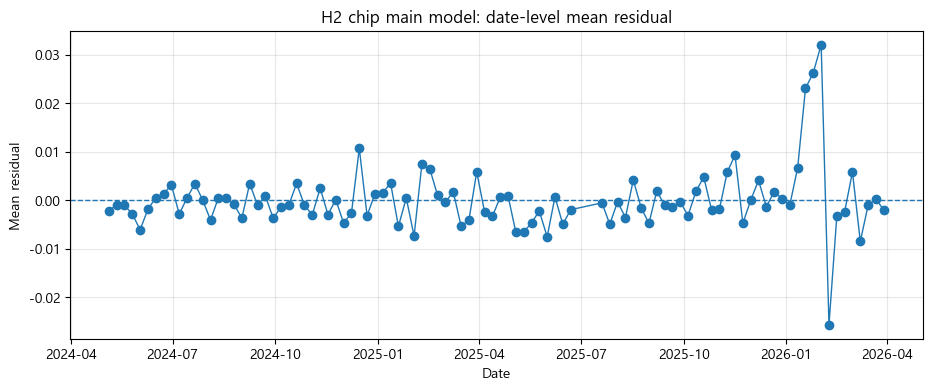

[saved plot] output_pic\hypo_2\H2_chip_main_residual_Q-Q_plot.png


<Figure size 500x500 with 0 Axes>

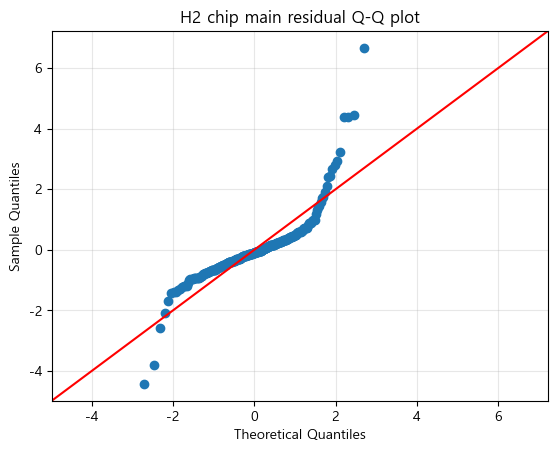

In [14]:
h2_resid = chip_reg[["date", "group", "gpu_ret"]].copy()
h2_resid["fitted"] = chip_mod.fittedvalues
h2_resid["resid"] = chip_mod.resid
h2_resid["std_resid"] = h2_resid["resid"] / h2_resid["resid"].std(ddof=1)
h2_resid["abs_std_resid"] = h2_resid["std_resid"].abs()

h2_resid_by_date = (
    h2_resid.groupby("date", as_index=False)
    .agg(mean_resid=("resid", "mean"), max_abs_std_resid=("abs_std_resid", "max"))
)
h2_resid_spikes = h2_resid.sort_values("abs_std_resid", ascending=False).head(10)

jb = stats.jarque_bera(h2_resid["resid"].dropna())
h2_resid_diag = pd.DataFrame([{
    "n": len(h2_resid),
    "resid_mean": h2_resid["resid"].mean(),
    "resid_std": h2_resid["resid"].std(ddof=1),
    "resid_skew": stats.skew(h2_resid["resid"].dropna()),
    "resid_kurtosis": stats.kurtosis(h2_resid["resid"].dropna(), fisher=False),
    "jarque_bera_stat": float(jb.statistic),
    "jarque_bera_p": float(jb.pvalue),
}])

print("H2 main residual distribution diagnostic")
display(h2_resid_diag.round(5))
print("Top H2 residual spikes")
display(h2_resid_spikes.round(5))

h2_resid.to_csv(H2_DIR / "chip_resid.csv", index=False)
h2_resid_by_date.to_csv(H2_DIR / "chip_resid_date.csv", index=False)
h2_resid_spikes.to_csv(H2_DIR / "chip_resid_top.csv", index=False)
h2_resid_diag.to_csv(H2_DIR / "chip_resid_diag.csv", index=False)

plt.figure(figsize=(11, 4))
plt.plot(h2_resid_by_date["date"], h2_resid_by_date["mean_resid"], marker="o", linewidth=1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("H2 chip main model: date-level mean residual")
plt.xlabel("Date")
plt.ylabel("Mean residual")
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

plt.figure(figsize=(5, 5))
sm.qqplot(h2_resid["resid"].dropna(), line="45", fit=True)
plt.title("H2 chip main residual Q-Q plot")
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>5. BTC × 성능군 상호작용항의 공동 유의성 및 누적 효과 검정</mark></b></span><br><br>

<b>[왜 공동 유의성 검정이 필요한가]</b><br>
BTC 반응은 특정 한 주 lag에서만 나타날 수도 있고, 여러 lag에 나누어 약하게 나타날 수도 있다. 따라서 개별 p-value만 보는 것보다 <b>BTC lag 0~8주 상호작용항 전체가 공동으로 0인지</b> 검정해야 한다.<br><br>

<b>[검정 내용: mid 기준]</b><br>
• <b>high-vs-mid interaction joint test</b>: high 그룹의 BTC 민감도가 mid 그룹과 같은가?<br>
• <b>low-vs-mid interaction joint test</b>: low 그룹의 BTC 민감도가 mid 그룹과 같은가?<br>
• <b>high-vs-low contrast</b>: high와 low의 민감도 차이가 있는가?<br>
• <b>all interaction joint test</b>: 성능군별 BTC 민감도 차이가 전체적으로 존재하는가?<br>
• <b>cumulative effect</b>: 0~8주 BTC 반응계수를 합산했을 때 mid/high/low 중 어느 그룹이 가장 크게 반응하는가?<br><br>

<b>[실행 후 해석]</b><br>
Hypo 2를 지지하려면 단순히 high 계수가 하나 양수인 정도가 아니라, <b>high-mid 또는 high-low 누적 차이</b>가 양수이고 공동 유의성 또는 누적 효과 검정에서 통계적 근거가 있어야 한다. 과도한 lag 변수로 인해 개별 계수의 표준오차가 커질 수 있으므로, 개별 lag의 유의성은 보조적으로만 본다.
</div>

In [15]:
def joint_test(model, terms, label, block):
    names = list(model.params.index)
    R = np.zeros((len(terms), len(names)))
    for i, term in enumerate(terms):
        R[i, names.index(term)] = 1.0
    test = model.f_test(R)
    return {
        "block": block,
        "test": label,
        "F_stat": float(np.asarray(test.fvalue).ravel()[0]),
        "p_value": float(np.asarray(test.pvalue).ravel()[0]),
        "df_num": float(test.df_num),
        "df_denom": float(test.df_denom),
    }


def joint_diff_test(model, pos_terms, neg_terms, label, block):
    names = list(model.params.index)
    R = np.zeros((len(pos_terms), len(names)))
    for i, (pos, neg) in enumerate(zip(pos_terms, neg_terms)):
        R[i, names.index(pos)] = 1.0
        R[i, names.index(neg)] = -1.0
    test = model.f_test(R)
    return {
        "block": block,
        "test": label,
        "F_stat": float(np.asarray(test.fvalue).ravel()[0]),
        "p_value": float(np.asarray(test.pvalue).ravel()[0]),
        "df_num": float(test.df_num),
        "df_denom": float(test.df_denom),
    }


def lin_combo_test(model, weights, label, block):
    names = list(model.params.index)
    R = np.zeros((1, len(names)))
    for term, weight in weights.items():
        R[0, names.index(term)] += weight
    test = model.t_test(R)
    return {
        "block": block,
        "test": label,
        "estimate": float(np.asarray(test.effect).ravel()[0]),
        "se": float(np.asarray(test.sd).ravel()[0]),
        "t": float(np.asarray(test.tvalue).ravel()[0]),
        "p_value": float(np.asarray(test.pvalue).ravel()[0]),
    }


def cum_test(model, terms, label, block):
    return lin_combo_test(model, {term: 1.0 for term in terms}, label, block)


def cum_diff_test(model, pos_terms, neg_terms, label, block):
    weights = {term: 1.0 for term in pos_terms}
    for term in neg_terms:
        weights[term] = weights.get(term, 0.0) - 1.0
    return lin_combo_test(model, weights, label, block)


def h2_test_block(model, block):
    joint_rows = [
        joint_test(model, hi_btc, "high_vs_mid_BTC_lags_joint_zero", block),
        joint_test(model, low_btc, "low_vs_mid_BTC_lags_joint_zero", block),
        joint_diff_test(model, hi_btc, low_btc, "high_vs_low_BTC_lags_joint_zero", block),
        joint_test(model, hi_btc + low_btc, "all_group_BTC_interactions_joint_zero", block),
    ]

    cumulative_rows = [
        cum_test(model, btc_lags, "mid_cumulative_BTC_effect", block),
        cum_test(model, btc_lags + hi_btc, "high_cumulative_BTC_effect", block),
        cum_test(model, btc_lags + low_btc, "low_cumulative_BTC_effect", block),
        cum_test(model, hi_btc, "high_minus_mid_cumulative_BTC_effect", block),
        cum_test(model, low_btc, "low_minus_mid_cumulative_BTC_effect", block),
        cum_diff_test(model, hi_btc, low_btc, "high_minus_low_cumulative_BTC_effect", block),
    ]
    return pd.DataFrame(joint_rows), pd.DataFrame(cumulative_rows)

joint_chip, cumulative_chip = h2_test_block(chip_mod, "chip_main")
joint_vram, cumulative_vram = h2_test_block(vram_mod, "vram_proxy")

main_joint = pd.concat([joint_chip, joint_vram], ignore_index=True)
main_cum = pd.concat([cumulative_chip, cumulative_vram], ignore_index=True)

print("H2 BTC interaction joint tests, mid as base")
display(main_joint.round(5))
print("H2 cumulative BTC effects, mid as base")
display(main_cum.round(5))

main_joint.to_csv(H2_DIR / "joint.csv", index=False)
main_cum.to_csv(H2_DIR / "cum.csv", index=False)

H2 BTC interaction joint tests, mid as base


,block,test,F_stat,p_value,df_num,df_denom
0,chip_main,high_vs_mid_BTC_lags_joint_zero,0.65533,0.74694,9.0,96.0
1,chip_main,low_vs_mid_BTC_lags_joint_zero,1.01484,0.43381,9.0,96.0
2,chip_main,high_vs_low_BTC_lags_joint_zero,0.45585,0.90043,9.0,96.0
3,chip_main,all_group_BTC_interactions_joint_zero,0.88121,0.60176,18.0,96.0
4,vram_proxy,high_vs_mid_BTC_lags_joint_zero,0.62646,0.77188,9.0,96.0
5,vram_proxy,low_vs_mid_BTC_lags_joint_zero,2.48160,0.01360,9.0,96.0
6,vram_proxy,high_vs_low_BTC_lags_joint_zero,0.97570,0.46504,9.0,96.0
7,vram_proxy,all_group_BTC_interactions_joint_zero,1.65144,0.06249,18.0,96.0


H2 cumulative BTC effects, mid as base


,block,test,estimate,se,t,p_value
0,chip_main,mid_cumulative_BTC_effect,0.04470,0.02561,1.74544,0.08091
1,chip_main,high_cumulative_BTC_effect,0.03759,0.03080,1.22030,0.22235
2,chip_main,low_cumulative_BTC_effect,0.05189,0.03859,1.34472,0.17872
3,chip_main,high_minus_mid_cumulative_BTC_effect,-0.00711,0.02399,-0.29639,0.76694
4,chip_main,low_minus_mid_cumulative_BTC_effect,0.00719,0.02713,0.26488,0.79110
5,chip_main,high_minus_low_cumulative_BTC_effect,-0.01430,0.03669,-0.38969,0.69677
6,vram_proxy,mid_cumulative_BTC_effect,0.04897,0.02907,1.68469,0.09205
7,vram_proxy,high_cumulative_BTC_effect,0.04795,0.03453,1.38875,0.16491
8,vram_proxy,low_cumulative_BTC_effect,-0.00093,0.01994,-0.04668,0.96277
9,vram_proxy,high_minus_mid_cumulative_BTC_effect,-0.00102,0.02231,-0.04587,0.96342


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>5-0. No-trim return robustness</mark></b></span><br><br>
<b>[왜 추가하는가]</b><br>
기본 성능군 수익률은 하드 오류 필터 이후 표본이 충분한 주에 5% 절사평균을 적용한다. 이 절사가 실제 crypto shock까지 약하게 만들었을 수 있으므로, EDA_process에서 저장한 <b>ret_chip_notrim_w</b>를 사용해 같은 interaction regression을 다시 수행한다.<br><br>
<b>[해석 기준]</b><br>
no-trim에서도 high-vs-mid, high-vs-low contrast와 누적효과 결론이 유지되면, Hypo 2의 결론이 절사평균 처리에 의존하지 않는다고 볼 수 있다.
</div>

In [16]:
ret_chip_nt_w = (
    pd.read_csv(OUT / "ret_chip_notrim_w.csv", parse_dates=["date"])
    .set_index("date")
    .sort_index()
)

h2_chip_nt = make_reg_df(ret_chip_nt_w, "chip_main_no_trim", chip_cols)
chip_nt_reg = h2_chip_nt[model_cols].dropna().copy()

chip_nt_mod, chip_nt_coef = fit_int(chip_nt_reg, "chip_main_no_trim")
nt_joint, nt_cum = h2_test_block(chip_nt_mod, "chip_main_no_trim")

nt_sample = pd.DataFrame([{
    "block": "chip_main_no_trim",
    "raw_rows": len(h2_chip_nt),
    "complete_reg_rows": len(chip_nt_reg),
    "week_n": chip_nt_reg["date"].nunique(),
}])

print("no-trim H2 sample")
display(nt_sample)
print("no-trim H2 joint tests")
display(nt_joint.round(5))
print("no-trim H2 cumulative effects")
display(nt_cum.round(5))

h2_chip_nt.to_csv(H2_DIR / "chip_notrim_raw.csv", index=False)
chip_nt_reg.to_csv(H2_DIR / "chip_notrim_reg.csv", index=False)
chip_nt_coef.to_csv(H2_DIR / "chip_notrim_coef.csv", index=False)
nt_joint.to_csv(H2_DIR / "chip_notrim_joint.csv", index=False)
nt_cum.to_csv(H2_DIR / "chip_notrim_cum.csv", index=False)
nt_sample.to_csv(H2_DIR / "chip_notrim_sample.csv", index=False)

no-trim H2 sample


,block,raw_rows,complete_reg_rows,week_n
0,chip_main_no_trim,315,291,97


no-trim H2 joint tests


,block,test,F_stat,p_value,df_num,df_denom
0,chip_main_no_trim,high_vs_mid_BTC_lags_joint_zero,0.39962,0.93245,9.0,96.0
1,chip_main_no_trim,low_vs_mid_BTC_lags_joint_zero,0.70314,0.70458,9.0,96.0
2,chip_main_no_trim,high_vs_low_BTC_lags_joint_zero,0.41951,0.92184,9.0,96.0
3,chip_main_no_trim,all_group_BTC_interactions_joint_zero,0.63363,0.86465,18.0,96.0


no-trim H2 cumulative effects


,block,test,estimate,se,t,p_value
0,chip_main_no_trim,mid_cumulative_BTC_effect,0.04441,0.03319,1.33780,0.18096
1,chip_main_no_trim,high_cumulative_BTC_effect,0.04911,0.04207,1.16744,0.24303
2,chip_main_no_trim,low_cumulative_BTC_effect,0.05022,0.05556,0.90387,0.36606
3,chip_main_no_trim,high_minus_mid_cumulative_BTC_effect,0.00470,0.03289,0.14304,0.88626
4,chip_main_no_trim,low_minus_mid_cumulative_BTC_effect,0.00581,0.05050,0.11512,0.90835
5,chip_main_no_trim,high_minus_low_cumulative_BTC_effect,-0.00111,0.05816,-0.01906,0.98479


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>5-1. 신제품·표본구성 효과 보완: composition-control robustness</mark></b></span><br><br>

<b>[수용한 피드백]</b><br>
신제품 출시나 단종은 high GPU 가격에 불연속적인 충격을 만들 수 있다. 다만 정확한 출시일 더미를 외부에서 임의로 넣으면 주관적 선택이 들어간다. 따라서 본분석 계수는 유지하되, 이미 생성된 데이터에서 관측되는 제품구성 변화 proxy를 통제한 강건성 회귀를 추가한다.<br><br>

<b>[추가 통제변수]</b><br>
• <b>log_active_product_n</b>: 해당 주차·성능군에서 수익률 패널에 들어온 활성 제품 수<br>
• <b>new_product_share</b>: 해당 주차·성능군에서 처음 관측된 제품 비율, 신제품/표본 진입 proxy<br>
• <b>bridge_ratio</b>: 전주에는 빠졌다가 전전주와 현재에 관측된 bridge gap 비율, 재고/관측 불안정성 proxy<br><br>

<b>[해석 기준]</b><br>
composition controls를 추가해도 high-minus-low BTC 누적효과의 방향과 유의성이 유지되면, Hypo 2 결과가 단순 제품구성 변화만으로 설명되기는 어렵다고 볼 수 있다. 반대로 결과가 크게 바뀌면 신제품·표본구성 효과에 민감한 결과로 제한적으로 해석한다.
</div>

In [17]:
comp_ctrls = ["log_active_product_n", "new_product_share", "bridge_ratio"]

comp_src = (
    comp_diag.rename(columns={"chip_perf_group": "group"})
    [["date", "group"] + comp_ctrls]
    .copy()
)

comp_reg = chip_reg.merge(comp_src, on=["date", "group"], how="left")

comp_reg = comp_reg.dropna(subset=["gpu_ret"] + x_cols + comp_ctrls).copy()

comp_x = x_cols + comp_ctrls

def fit_custom(dat, rhs, block_name):
    y = dat["gpu_ret"].astype(float)
    X = sm.add_constant(dat[rhs].astype(float), has_constant="add")
    model = sm.OLS(y, X).fit(
        cov_type="cluster",
        cov_kwds={"groups": dat["date"]}
    )
    coef = pd.DataFrame({
        "term": model.params.index,
        "coef": model.params.values,
        "se": model.bse.values,
        "t": model.tvalues.values,
        "p_value": model.pvalues.values,
        "block": block_name,
    })
    return model, coef

h2_comp_model, h2_comp_coef = fit_custom(
    comp_reg,
    comp_x,
    "chip_main_composition_control",
)

comp_joint, comp_cum = h2_test_block(
    h2_comp_model,
    "chip_main_composition_control",
)

composition_sample = pd.DataFrame([{
    "block": "chip_main_composition_control",
    "obs_n": len(comp_reg),
    "week_n": comp_reg["date"].nunique(),
    "group_n": comp_reg["group"].nunique(),
}])

print("composition-control model summary")
print(h2_comp_model.summary())
print("composition-control sample")
display(composition_sample)
print("composition-control joint tests")
display(comp_joint.round(5))
print("composition-control cumulative effects")
display(comp_cum.round(5))

comp_reg.to_csv(H2_DIR / "comp_reg.csv", index=False)
h2_comp_coef.to_csv(H2_DIR / "comp_coef.csv", index=False)
comp_joint.to_csv(H2_DIR / "comp_joint.csv", index=False)
comp_cum.to_csv(H2_DIR / "comp_cum.csv", index=False)
composition_sample.to_csv(H2_DIR / "comp_sample.csv", index=False)

composition-control model summary
                            OLS Regression Results                            
Dep. Variable:                gpu_ret   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.367
Method:                 Least Squares   F-statistic:                     3.749
Date:                Mon, 04 May 2026   Prob (F-statistic):           7.67e-08
Time:                        14:12:04   Log-Likelihood:                 1015.0
No. Observations:                 291   AIC:                            -1950.
Df Residuals:                     251   BIC:                            -1803.
Df Model:                          39                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

,block,obs_n,week_n,group_n
0,chip_main_composition_control,291,97,3


composition-control joint tests


,block,test,F_stat,p_value,df_num,df_denom
0,chip_main_composition_control,high_vs_mid_BTC_lags_joint_zero,0.63874,0.76134,9.0,96.0
1,chip_main_composition_control,low_vs_mid_BTC_lags_joint_zero,0.88025,0.54573,9.0,96.0
2,chip_main_composition_control,high_vs_low_BTC_lags_joint_zero,0.43407,0.91356,9.0,96.0
3,chip_main_composition_control,all_group_BTC_interactions_joint_zero,0.70196,0.80138,18.0,96.0


composition-control cumulative effects


,block,test,estimate,se,t,p_value
0,chip_main_composition_control,mid_cumulative_BTC_effect,0.04488,0.02560,1.75264,0.07966
1,chip_main_composition_control,high_cumulative_BTC_effect,0.03388,0.03077,1.10116,0.27083
2,chip_main_composition_control,low_cumulative_BTC_effect,0.05980,0.03906,1.53077,0.12583
3,chip_main_composition_control,high_minus_mid_cumulative_BTC_effect,-0.01099,0.02481,-0.44304,0.65774
4,chip_main_composition_control,low_minus_mid_cumulative_BTC_effect,0.01492,0.02758,0.54116,0.58840
5,chip_main_composition_control,high_minus_low_cumulative_BTC_effect,-0.02591,0.03855,-0.67231,0.50138


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>5-2. Lag 변수 과다 문제 보완: lag-window 축약 강건성 분석</mark></b></span><br><br>

<b>[왜 추가하는가]</b><br>
BTC lag 0~8주와 그 상호작용항을 모두 넣으면 설명변수가 많아지고 lag끼리 상관이 생길 수 있다. 따라서 본모형은 유지하되, lag를 몇 개의 구간으로 묶은 축약 모형을 추가해 결과가 lag 세부 설정에 과도하게 의존하는지 확인한다.<br><br>

<b>[lag window 정의]</b><br>
• <b>w0</b>: 당주 BTC 수익률<br>
• <b>w1_2</b>: 1~2주 전 BTC 누적 수익률<br>
• <b>w3_5</b>: 3~5주 전 BTC 누적 수익률<br>
• <b>w6_8</b>: 6~8주 전 BTC 누적 수익률<br><br>

<b>[해석 기준]</b><br>
축약 모형에서도 high-minus-low 누적 BTC 효과가 같은 방향이면, 결과가 특정 단일 lag 선택에만 의존하지 않는다는 보조 근거가 된다. 반대로 방향이 불안정하면 lag 구조에 민감한 결과로 해석한다.
</div>

In [18]:
LAG_WIN = {
    "w0": [0],
    "w1_2": [1, 2],
    "w3_5": [3, 4, 5],
    "w6_8": [6, 7, 8],
}

win_df = chip_reg.copy()

btc_win = []
hi_win = []
low_win = []

for name, lags in LAG_WIN.items():
    base_col = f"btc_{name}"
    high_col = f"high_btc_{name}"
    low_col = f"low_btc_{name}"

    win_df[base_col] = win_df[[f"btc_krw_ret_l{k}" for k in lags]].sum(axis=1)
    win_df[high_col] = win_df["is_high"] * win_df[base_col]
    win_df[low_col] = win_df["is_low"] * win_df[base_col]

    btc_win.append(base_col)
    hi_win.append(high_col)
    low_win.append(low_col)

win_x = (
    ["is_high", "is_low"]
    + btc_win
    + hi_win
    + low_win
    + ["fx_ret", "nvda_ret", "high_fx_ret", "low_fx_ret", "high_nvda_ret", "low_nvda_ret", "gpu_ret_l1"]
)

h2_window_reg = win_df[["gpu_ret", "date", "group"] + win_x].dropna().copy()

h2_window_model, h2_window_coef = fit_custom(
    h2_window_reg,
    win_x,
    "chip_main_lag_window",
)

win_joint = pd.DataFrame([
    joint_test(h2_window_model, hi_win, "window_high_vs_mid_BTC_joint_zero", "chip_main_lag_window"),
    joint_test(h2_window_model, low_win, "window_low_vs_mid_BTC_joint_zero", "chip_main_lag_window"),
    joint_diff_test(h2_window_model, hi_win, low_win, "window_high_vs_low_BTC_joint_zero", "chip_main_lag_window"),
    joint_test(h2_window_model, hi_win + low_win, "window_all_group_BTC_interactions_joint_zero", "chip_main_lag_window"),
])

win_cum = pd.DataFrame([
    cum_test(h2_window_model, btc_win, "window_mid_cumulative_BTC_effect", "chip_main_lag_window"),
    cum_test(h2_window_model, btc_win + hi_win, "window_high_cumulative_BTC_effect", "chip_main_lag_window"),
    cum_test(h2_window_model, btc_win + low_win, "window_low_cumulative_BTC_effect", "chip_main_lag_window"),
    cum_test(h2_window_model, hi_win, "window_high_minus_mid_cumulative_BTC_effect", "chip_main_lag_window"),
    cum_test(h2_window_model, low_win, "window_low_minus_mid_cumulative_BTC_effect", "chip_main_lag_window"),
    cum_diff_test(h2_window_model, hi_win, low_win, "window_high_minus_low_cumulative_BTC_effect", "chip_main_lag_window"),
])

window_sample = pd.DataFrame([{
    "block": "chip_main_lag_window",
    "obs_n": len(h2_window_reg),
    "week_n": h2_window_reg["date"].nunique(),
    "group_n": h2_window_reg["group"].nunique(),
    "base_group": BASE,
    "lag_window_n": len(LAG_WIN),
}])

print("lag-window compact model summary")
print(h2_window_model.summary())
print("lag-window sample")
display(window_sample)
print("lag-window joint tests")
display(win_joint.round(5))
print("lag-window cumulative effects")
display(win_cum.round(5))

h2_window_reg.to_csv(H2_DIR / "win_reg.csv", index=False)
h2_window_coef.to_csv(H2_DIR / "win_coef.csv", index=False)
win_joint.to_csv(H2_DIR / "win_joint.csv", index=False)
win_cum.to_csv(H2_DIR / "win_cum.csv", index=False)
window_sample.to_csv(H2_DIR / "win_sample.csv", index=False)

lag-window compact model summary
                            OLS Regression Results                            
Dep. Variable:                gpu_ret   R-squared:                       0.420
Model:                            OLS   Adj. R-squared:                  0.374
Method:                 Least Squares   F-statistic:                     3.220
Date:                Mon, 04 May 2026   Prob (F-statistic):           5.15e-05
Time:                        14:12:09   Log-Likelihood:                 1006.6
No. Observations:                 291   AIC:                            -1969.
Df Residuals:                     269   BIC:                            -1888.
Df Model:                          21                                         
Covariance Type:              cluster                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const        

,block,obs_n,week_n,group_n,base_group,lag_window_n
0,chip_main_lag_window,291,97,3,mid,4


lag-window joint tests


,block,test,F_stat,p_value,df_num,df_denom
0,chip_main_lag_window,window_high_vs_mid_BTC_joint_zero,1.06734,0.37701,4.0,96.0
1,chip_main_lag_window,window_low_vs_mid_BTC_joint_zero,0.43166,0.78544,4.0,96.0
2,chip_main_lag_window,window_high_vs_low_BTC_joint_zero,0.79362,0.53216,4.0,96.0
3,chip_main_lag_window,window_all_group_BTC_interactions_joint_zero,0.78495,0.61699,8.0,96.0


lag-window cumulative effects


,block,test,estimate,se,t,p_value
0,chip_main_lag_window,window_mid_cumulative_BTC_effect,0.01620,0.01460,1.11016,0.26693
1,chip_main_lag_window,window_high_cumulative_BTC_effect,0.01823,0.01456,1.25235,0.21044
2,chip_main_lag_window,window_low_cumulative_BTC_effect,0.02328,0.02054,1.13371,0.25692
3,chip_main_lag_window,window_high_minus_mid_cumulative_BTC_effect,0.00202,0.01303,0.15535,0.87654
4,chip_main_lag_window,window_low_minus_mid_cumulative_BTC_effect,0.00708,0.01351,0.52402,0.60026
5,chip_main_lag_window,window_high_minus_low_cumulative_BTC_effect,-0.00506,0.01912,-0.26442,0.79145


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>5-3. Almon distributed lag robustness</mark></b></span><br><br>
<b>[왜 추가하는가]</b><br>
BTC lag 0~8주와 성능군 상호작용을 모두 넣으면 BTC 관련 파라미터가 많아진다. Almon distributed lag는 lag별 계수를 낮은 차수의 다항식으로 제한하여 파라미터 수를 줄이는 축약 모형이다.<br><br>
<b>[해석 기준]</b><br>
Almon 모형에서도 high-vs-mid 또는 high-vs-low 누적효과가 유의하지 않으면, 본모형의 비유의성이 단순히 자유도 낭비 때문이라고 보기 어렵다.
</div>

In [19]:
ALMON_DEGREE = 2
almon_df = chip_reg.copy()
lag_idx = np.arange(L + 1)
lag_power_sum = {d: float(np.sum(lag_idx ** d)) for d in range(ALMON_DEGREE + 1)}

almon_base = []
almon_high = []
almon_low = []

for d in range(ALMON_DEGREE + 1):
    base_col = f"btc_poly_d{d}"
    high_col = f"high_btc_poly_d{d}"
    low_col = f"low_btc_poly_d{d}"

    almon_df[base_col] = 0.0
    for k in range(L + 1):
        almon_df[base_col] += (k ** d) * almon_df[f"btc_krw_ret_l{k}"]

    almon_df[high_col] = almon_df["is_high"] * almon_df[base_col]
    almon_df[low_col] = almon_df["is_low"] * almon_df[base_col]

    almon_base.append(base_col)
    almon_high.append(high_col)
    almon_low.append(low_col)

almon_x = (
    ["is_high", "is_low"]
    + almon_base
    + almon_high
    + almon_low
    + ["fx_ret", "nvda_ret", "high_fx_ret", "low_fx_ret", "high_nvda_ret", "low_nvda_ret", "gpu_ret_l1"]
)

almon_reg = almon_df[["gpu_ret", "date", "group"] + almon_x].dropna().copy()
almon_mod, almon_coef = fit_custom(almon_reg, almon_x, "chip_main_almon")

almon_joint = pd.DataFrame([
    joint_test(almon_mod, almon_high, "almon_high_vs_mid_BTC_joint_zero", "chip_main_almon"),
    joint_test(almon_mod, almon_low, "almon_low_vs_mid_BTC_joint_zero", "chip_main_almon"),
    joint_diff_test(almon_mod, almon_high, almon_low, "almon_high_vs_low_BTC_joint_zero", "chip_main_almon"),
    joint_test(almon_mod, almon_high + almon_low, "almon_all_group_BTC_interactions_joint_zero", "chip_main_almon"),
])

mid_weights = {col: lag_power_sum[d] for d, col in enumerate(almon_base)}
high_weights = mid_weights.copy()
high_weights.update({col: lag_power_sum[d] for d, col in enumerate(almon_high)})
low_weights = mid_weights.copy()
low_weights.update({col: lag_power_sum[d] for d, col in enumerate(almon_low)})
high_minus_mid_weights = {col: lag_power_sum[d] for d, col in enumerate(almon_high)}
low_minus_mid_weights = {col: lag_power_sum[d] for d, col in enumerate(almon_low)}
high_minus_low_weights = {col: lag_power_sum[d] for d, col in enumerate(almon_high)}
for d, col in enumerate(almon_low):
    high_minus_low_weights[col] = -lag_power_sum[d]

almon_cum = pd.DataFrame([
    lin_combo_test(almon_mod, mid_weights, "almon_mid_cumulative_BTC_effect", "chip_main_almon"),
    lin_combo_test(almon_mod, high_weights, "almon_high_cumulative_BTC_effect", "chip_main_almon"),
    lin_combo_test(almon_mod, low_weights, "almon_low_cumulative_BTC_effect", "chip_main_almon"),
    lin_combo_test(almon_mod, high_minus_mid_weights, "almon_high_minus_mid_cumulative_BTC_effect", "chip_main_almon"),
    lin_combo_test(almon_mod, low_minus_mid_weights, "almon_low_minus_mid_cumulative_BTC_effect", "chip_main_almon"),
    lin_combo_test(almon_mod, high_minus_low_weights, "almon_high_minus_low_cumulative_BTC_effect", "chip_main_almon"),
])

almon_sample = pd.DataFrame([{
    "block": "chip_main_almon",
    "obs_n": len(almon_reg),
    "week_n": almon_reg["date"].nunique(),
    "group_n": almon_reg["group"].nunique(),
    "base_group": BASE,
    "almon_degree": ALMON_DEGREE,
    "parameter_note": "BTC lag terms compressed into polynomial basis",
}])

print("Almon distributed lag model summary")
print(almon_mod.summary())
print("Almon sample")
display(almon_sample)
print("Almon joint tests")
display(almon_joint.round(5))
print("Almon cumulative effects")
display(almon_cum.round(5))

almon_reg.to_csv(H2_DIR / "almon_reg.csv", index=False)
almon_coef.to_csv(H2_DIR / "almon_coef.csv", index=False)
almon_joint.to_csv(H2_DIR / "almon_joint.csv", index=False)
almon_cum.to_csv(H2_DIR / "almon_cum.csv", index=False)
almon_sample.to_csv(H2_DIR / "almon_sample.csv", index=False)

Almon distributed lag model summary
                            OLS Regression Results                            
Dep. Variable:                gpu_ret   R-squared:                       0.411
Model:                            OLS   Adj. R-squared:                  0.372
Method:                 Least Squares   F-statistic:                     2.840
Date:                Mon, 04 May 2026   Prob (F-statistic):           0.000535
Time:                        14:12:14   Log-Likelihood:                 1004.4
No. Observations:                 291   AIC:                            -1971.
Df Residuals:                     272   BIC:                            -1901.
Df Model:                          18                                         
Covariance Type:              cluster                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
cons

,block,obs_n,week_n,group_n,base_group,almon_degree,parameter_note
0,chip_main_almon,291,97,3,mid,2,BTC lag terms compressed into polynomial basis


Almon joint tests


,block,test,F_stat,p_value,df_num,df_denom
0,chip_main_almon,almon_high_vs_mid_BTC_joint_zero,0.58369,0.62713,3.0,96.0
1,chip_main_almon,almon_low_vs_mid_BTC_joint_zero,0.40768,0.74783,3.0,96.0
2,chip_main_almon,almon_high_vs_low_BTC_joint_zero,0.70549,0.55104,3.0,96.0
3,chip_main_almon,almon_all_group_BTC_interactions_joint_zero,0.38383,0.88775,6.0,96.0


Almon cumulative effects


,block,test,estimate,se,t,p_value
0,chip_main_almon,almon_mid_cumulative_BTC_effect,0.04679,0.02444,1.91465,0.05554
1,chip_main_almon,almon_high_cumulative_BTC_effect,0.03926,0.02940,1.33533,0.18177
2,chip_main_almon,almon_low_cumulative_BTC_effect,0.05126,0.03628,1.41280,0.15771
3,chip_main_almon,almon_high_minus_mid_cumulative_BTC_effect,-0.00752,0.02239,-0.33608,0.73681
4,chip_main_almon,almon_low_minus_mid_cumulative_BTC_effect,0.00447,0.02772,0.16126,0.87189
5,chip_main_almon,almon_high_minus_low_cumulative_BTC_effect,-0.01199,0.03494,-0.34324,0.73142


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>6. 성능군별 BTC lag 계수 시각화</mark></b></span><br><br>

<b>[왜 시각화하는가]</b><br>
공동 유의성 검정은 p-value로 요약되지만, 발표에서는 어느 lag에서 high/mid/low 반응이 갈라지는지 보여주는 그래프가 필요하다. 따라서 mid 기준 회귀계수를 성능군별 lag profile로 다시 복원한다.<br><br>

<b>[계산 방식]</b><br>
• mid 계수: BTC lag 기본 계수<br>
• high 계수: BTC lag 기본 계수 + high_btc interaction 계수<br>
• low 계수: BTC lag 기본 계수 + low_btc interaction 계수<br><br>

<b>[실행 후 해석]</b><br>
high 그룹의 계수선이 mid와 low보다 일관되게 위에 있으면 Hypo 2 방향성과 맞는다. 그러나 신뢰구간이 넓거나 0을 자주 포함하면 “방향성은 보이나 통계적으로 강하지 않다”로 해석해야 한다.
</div>

chip group-specific BTC lag coefficients


,block,base_group,group,lag_week,term_label,coef,se,p_value
0,chip_main,mid,mid,0,mid_l0,-0.01353,0.01793,0.45043
1,chip_main,mid,high,0,high_l0,-0.00190,0.01886,0.91964
2,chip_main,mid,low,0,low_l0,0.00112,0.01944,0.95426
3,chip_main,mid,mid,1,mid_l1,0.01892,0.01813,0.29676
4,chip_main,mid,high,1,high_l1,0.00905,0.01547,0.55827
5,chip_main,mid,low,1,low_l1,-0.00298,0.02050,0.88456
6,chip_main,mid,mid,2,mid_l2,0.02999,0.02089,0.15108
7,chip_main,mid,high,2,high_l2,0.02947,0.01650,0.07412
8,chip_main,mid,low,2,low_l2,0.04393,0.03034,0.14761
9,chip_main,mid,mid,3,mid_l3,-0.01718,0.00939,0.06747


[saved plot] output_pic\hypo_2\Hypo_2_group-specific_BTC_lag_coefficients,_chip_main.png


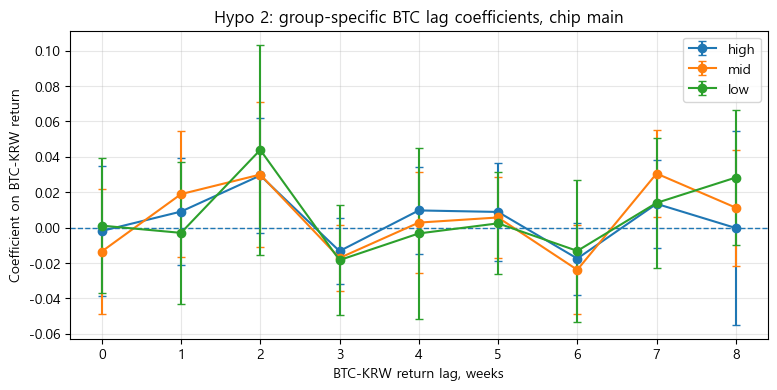

In [20]:
def lin_est(model, terms, label, group, lag, block):
    names = list(model.params.index)
    R = np.zeros((1, len(names)))
    for term in terms:
        R[0, names.index(term)] += 1.0
    test = model.t_test(R)
    return {
        "block": block,
        "base_group": BASE,
        "group": group,
        "lag_week": lag,
        "term_label": label,
        "coef": float(np.asarray(test.effect).ravel()[0]),
        "se": float(np.asarray(test.sd).ravel()[0]),
        "p_value": float(np.asarray(test.pvalue).ravel()[0]),
    }


def lag_coef_table(model, block):
    rows = []
    for k in range(L + 1):
        base = f"btc_krw_ret_l{k}"
        rows.append(lin_est(model, [base], f"mid_l{k}", "mid", k, block))
        rows.append(lin_est(model, [base, f"high_btc_l{k}"], f"high_l{k}", "high", k, block))
        rows.append(lin_est(model, [base, f"low_btc_l{k}"], f"low_l{k}", "low", k, block))
    return pd.DataFrame(rows)

chip_lag_coef = lag_coef_table(chip_mod, "chip_main")
vram_lag_coef = lag_coef_table(vram_mod, "vram_proxy")

print("chip group-specific BTC lag coefficients")
display(chip_lag_coef.round(5))
chip_lag_coef.to_csv(H2_DIR / "chip_lag.csv", index=False)
vram_lag_coef.to_csv(H2_DIR / "vram_lag.csv", index=False)

plt.figure(figsize=(9, 4))
for group in GROUPS:
    sub = chip_lag_coef[chip_lag_coef["group"] == group].sort_values("lag_week")
    plt.errorbar(
        sub["lag_week"],
        sub["coef"],
        yerr=1.96 * sub["se"],
        marker="o",
        capsize=3,
        label=group,
    )
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Hypo 2: group-specific BTC lag coefficients, chip main")
plt.xlabel("BTC-KRW return lag, weeks")
plt.ylabel("Coefficient on BTC-KRW return")
plt.legend()
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>7. 다중공선성 점검: BTC, 환율, NVDA</mark></b></span><br><br>

<b>[왜 VIF를 확인하는가]</b><br>
BTC와 NVDA는 일부 기간에 함께 상승하거나 하락할 수 있다. 이 경우 회귀계수 자체가 틀렸다는 뜻은 아니지만, 표준오차가 커져서 유의성이 약해질 수 있다. 따라서 주요 시장변수의 VIF를 확인한다.<br><br>

<b>[해석 기준]</b><br>
• VIF가 5 미만이면 대체로 큰 문제는 아니라고 본다.<br>
• VIF가 10 이상이면 다중공선성 가능성을 강하게 의심한다.<br>
• BTC lag를 0~8주까지 많이 넣는 모델에서는 lag끼리의 상관 때문에 VIF가 커질 수 있으므로, 이 경우 개별 lag p-value보다 공동 유의성 검정과 누적 효과를 함께 해석한다.
</div>

In [21]:
def get_vif(df, cols, block):
    X = df[cols].dropna().astype(float).copy()
    X = sm.add_constant(X)
    rows = []
    for i, col in enumerate(X.columns):
        rows.append({
            "block": block,
            "variable": col,
            "VIF": variance_inflation_factor(X.values, i),
        })
    return pd.DataFrame(rows)

vif_core = get_vif(chip_reg, ["btc_krw_ret_l0", "fx_ret", "nvda_ret", "gpu_ret_l1"], "chip_core")
vif_full = get_vif(chip_reg, btc_lags + ["fx_ret", "nvda_ret", "gpu_ret_l1"], "chip_lag_full")

print("VIF core")
display(vif_core.round(3))
print("VIF with BTC lags")
display(vif_full.round(3))

vif_core.to_csv(H2_DIR / "vif_core.csv", index=False)
vif_full.to_csv(H2_DIR / "vif_full.csv", index=False)

VIF core


,block,variable,VIF
0,chip_core,const,1.065
1,chip_core,btc_krw_ret_l0,1.225
2,chip_core,fx_ret,1.037
3,chip_core,nvda_ret,1.099
4,chip_core,gpu_ret_l1,1.156


VIF with BTC lags


,block,variable,VIF
0,chip_lag_full,const,1.077
1,chip_lag_full,btc_krw_ret_l0,1.407
2,chip_lag_full,btc_krw_ret_l1,1.395
3,chip_lag_full,btc_krw_ret_l2,1.437
4,chip_lag_full,btc_krw_ret_l3,1.386
5,chip_lag_full,btc_krw_ret_l4,1.420
6,chip_lag_full,btc_krw_ret_l5,1.273
7,chip_lag_full,btc_krw_ret_l6,1.260
8,chip_lag_full,btc_krw_ret_l7,1.276
9,chip_lag_full,btc_krw_ret_l8,1.215


<div style="line-height: 1.8;">
<br>
<span style="font-size: 20px;"><b><mark>7-1. NASDAQ/SOX 통제는 H2 본모형에 넣지 않는 이유</mark></b></span><br><br>
Hypo 2의 질문은 성능군별 BTC 민감도 차이이다. 이미 NVDA와 NVDA×성능군 interaction을 넣어 AI/반도체 수요가 성능군별로 다르게 작용할 가능성을 통제했다. 여기에 NASDAQ/SOX와 그 interaction까지 모두 넣으면 표본 대비 설명변수가 과도하게 늘고, NVDA와 중복되는 기술주·반도체 요인을 과통제할 수 있다. 따라서 NASDAQ/SOX는 Hypo 1의 확장 시장통제 robustness에서 우선 확인하고, Hypo 2에서는 NVDA interaction과 product-composition robustness를 핵심 통제로 유지한다.<br><br>
</div>

VRAM proxy model summary
                            OLS Regression Results                            
Dep. Variable:                gpu_ret   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.443
Method:                 Least Squares   F-statistic:                     5.111
Date:                Mon, 04 May 2026   Prob (F-statistic):           8.77e-11
Time:                        14:12:26   Log-Likelihood:                 1073.7
No. Observations:                 291   AIC:                            -2073.
Df Residuals:                     254   BIC:                            -1937.
Df Model:                          36                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              

,block,test,F_stat,p_value,df_num,df_denom
4,vram_proxy,high_vs_mid_BTC_lags_joint_zero,0.62646,0.77188,9.0,96.0
5,vram_proxy,low_vs_mid_BTC_lags_joint_zero,2.48160,0.01360,9.0,96.0
6,vram_proxy,high_vs_low_BTC_lags_joint_zero,0.97570,0.46504,9.0,96.0
7,vram_proxy,all_group_BTC_interactions_joint_zero,1.65144,0.06249,18.0,96.0


VRAM proxy cumulative effects


,block,test,estimate,se,t,p_value
6,vram_proxy,mid_cumulative_BTC_effect,0.04897,0.02907,1.68469,0.09205
7,vram_proxy,high_cumulative_BTC_effect,0.04795,0.03453,1.38875,0.16491
8,vram_proxy,low_cumulative_BTC_effect,-0.00093,0.01994,-0.04668,0.96277
9,vram_proxy,high_minus_mid_cumulative_BTC_effect,-0.00102,0.02231,-0.04587,0.96342
10,vram_proxy,low_minus_mid_cumulative_BTC_effect,-0.04990,0.03464,-1.44069,0.14967
11,vram_proxy,high_minus_low_cumulative_BTC_effect,0.04888,0.04099,1.19242,0.23310


[saved plot] output_pic\hypo_2\Hypo_2_robustness_VRAM_proxy_group_price_index.png


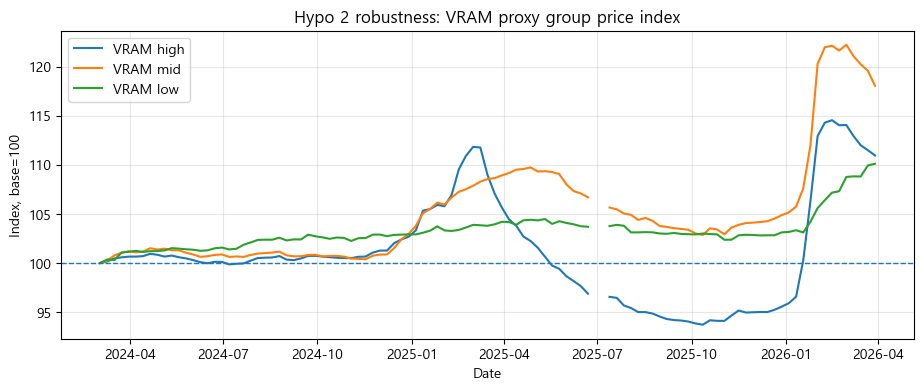

[saved plot] output_pic\hypo_2\Hypo_2_group-specific_BTC_lag_coefficients,_VRAM_proxy.png


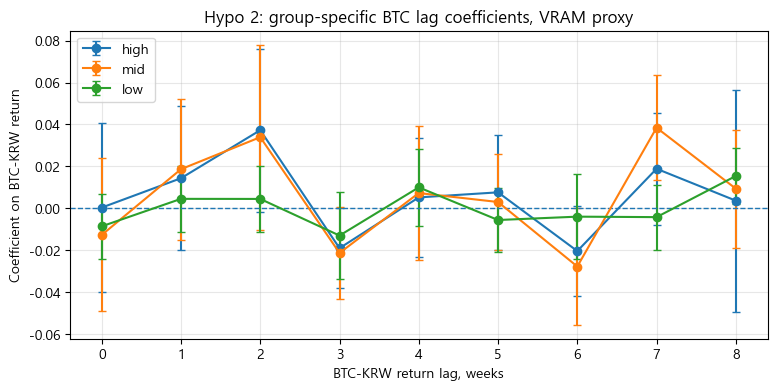

In [22]:
print("VRAM proxy model summary")
print(vram_mod.summary())

print("VRAM proxy joint tests")
display(main_joint[main_joint["block"] == "vram_proxy"].round(5))

print("VRAM proxy cumulative effects")
display(main_cum[main_cum["block"] == "vram_proxy"].round(5))

plt.figure(figsize=(11, 4))
for g in vram_cols:
    plt.plot(idx_vram_w.index, idx_vram_w[g], label=f"VRAM {g}")
plt.axhline(100, linestyle="--", linewidth=1)
plt.title("Hypo 2 robustness: VRAM proxy group price index")
plt.xlabel("Date")
plt.ylabel("Index, base=100")
plt.legend()
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

plt.figure(figsize=(9, 4))
for group in GROUPS:
    sub = vram_lag_coef[vram_lag_coef["group"] == group].sort_values("lag_week")
    plt.errorbar(
        sub["lag_week"],
        sub["coef"],
        yerr=1.96 * sub["se"],
        marker="o",
        capsize=3,
        label=group,
    )
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Hypo 2: group-specific BTC lag coefficients, VRAM proxy")
plt.xlabel("BTC-KRW return lag, weeks")
plt.ylabel("Coefficient on BTC-KRW return")
plt.legend()
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>9. 제품 단위 패널 강건성: product fixed effect</mark></b></span><br><br>

<b>[왜 제품 단위 패널을 추가하는가]</b><br>
성능군별 지수는 high/mid/low 세 개의 주간 시계열이므로 표본 수가 제한적이다. 이미 저장된 <b>panel_gpu.csv</b>에는 제품-주 단위 로그수익률이 있으므로, 제품 단위에서 같은 결론이 유지되는지 확인한다.<br><br>

<b>[product fixed effect 의미]</b><br>
제품마다 평균 가격 수준, 브랜드, 라인업, 기본 할인 패턴이 다를 수 있다. 이를 제거하기 위해 각 제품별 평균을 빼는 within transformation을 사용한다. 이렇게 하면 제품 고유 특성은 제거되고, 시간에 따라 변하는 BTC/FX/NVDA와 성능군 상호작용만 남는다.<br><br>

<b>[주의]</b><br>
제품 단위 패널은 같은 주차의 시장변수를 모든 제품이 공유하므로, 표준오차는 date 기준 cluster-robust로 계산한다. 제품 고정효과는 제품 고유 특성은 제거하지만, 제품이 새로 등장하는 시점 자체의 충격을 완벽히 제거하지는 못한다. 따라서 이 분석은 본분석을 대체하는 것이 아니라 <b>강건성 확인</b>이다.
</div>

In [23]:
panel = panel_gpu[panel_gpu["chip_perf_group"].isin(GROUPS)].copy()
panel = panel.merge(mkt.reset_index().rename(columns={mkt.index.name or "index": "date"}), on="date", how="inner")
panel = panel.sort_values(["row_id", "date"]).copy()

panel["is_high"] = (panel["chip_perf_group"] == "high").astype(int)
panel["is_low"] = (panel["chip_perf_group"] == "low").astype(int)

for col in btc_lags:
    lag = col.replace("btc_krw_ret_l", "")
    panel[f"high_btc_l{lag}"] = panel["is_high"] * panel[col]
    panel[f"low_btc_l{lag}"] = panel["is_low"] * panel[col]

panel["high_nvda_ret"] = panel["is_high"] * panel["nvda_ret"]
panel["low_nvda_ret"] = panel["is_low"] * panel["nvda_ret"]
panel["high_fx_ret"] = panel["is_high"] * panel["fx_ret"]
panel["low_fx_ret"] = panel["is_low"] * panel["fx_ret"]

prod_x = (
    btc_lags
    + hi_btc
    + low_btc
    + ["fx_ret", "nvda_ret", "high_fx_ret", "low_fx_ret", "high_nvda_ret", "low_nvda_ret"]
)
prod_reg = panel[["row_id", "date", "gpu_log_return", "chip_perf_group"] + prod_x].dropna().copy()

within_cols = ["gpu_log_return"] + prod_x
prod_dm = prod_reg[within_cols] - prod_reg.groupby("row_id")[within_cols].transform("mean")

y_fe = prod_dm["gpu_log_return"].astype(float)
X_fe = prod_dm[prod_x].astype(float)

prod_mod = sm.OLS(y_fe, X_fe).fit(
    cov_type="cluster",
    cov_kwds={"groups": prod_reg["date"]}
)

prod_coef = pd.DataFrame({
    "term": prod_mod.params.index,
    "coef": prod_mod.params.values,
    "se": prod_mod.bse.values,
    "t": prod_mod.tvalues.values,
    "p_value": prod_mod.pvalues.values,
    "base_group": BASE,
})

prod_sample = pd.DataFrame([{
    "obs_n": len(prod_reg),
    "product_n": prod_reg["row_id"].nunique(),
    "week_n": prod_reg["date"].nunique(),
    "base_group": BASE,
}])

print(prod_mod.summary())
print("product FE panel sample")
display(prod_sample)
print("product FE coefficient table")
display(prod_coef.round(5))

prod_joint, prod_cum = h2_test_block(prod_mod, "product_FE")

print("product FE joint tests")
display(prod_joint.round(5))
print("product FE cumulative effects")
display(prod_cum.round(5))

prod_sample.to_csv(H2_DIR / "prod_fe_sample.csv", index=False)
prod_coef.to_csv(H2_DIR / "prod_fe_coef.csv", index=False)
prod_joint.to_csv(H2_DIR / "prod_fe_joint.csv", index=False)
prod_cum.to_csv(H2_DIR / "prod_fe_cum.csv", index=False)

                                 OLS Regression Results                                
Dep. Variable:         gpu_log_return   R-squared (uncentered):                   0.005
Model:                            OLS   Adj. R-squared (uncentered):              0.004
Method:                 Least Squares   F-statistic:                              2.239
Date:                Mon, 04 May 2026   Prob (F-statistic):                     0.00127
Time:                        14:12:32   Log-Likelihood:                          88058.
No. Observations:               66091   AIC:                                 -1.761e+05
Df Residuals:                   66058   BIC:                                 -1.758e+05
Df Model:                          33                                                  
Covariance Type:              cluster                                                  
                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------

,obs_n,product_n,week_n,base_group
0,66091,1840,97,mid


product FE coefficient table


,term,coef,se,t,p_value,base_group
0,btc_krw_ret_l0,-0.09120,0.03772,-2.41749,0.01563,mid
1,btc_krw_ret_l1,0.00311,0.03341,0.09320,0.92574,mid
2,btc_krw_ret_l2,0.03176,0.03575,0.88826,0.37440,mid
3,btc_krw_ret_l3,-0.01147,0.01735,-0.66115,0.50852,mid
4,btc_krw_ret_l4,0.02110,0.01916,1.10120,0.27081,mid
5,btc_krw_ret_l5,0.01281,0.02386,0.53692,0.59132,mid
6,btc_krw_ret_l6,-0.01959,0.02536,-0.77249,0.43983,mid
7,btc_krw_ret_l7,0.01758,0.02158,0.81485,0.41516,mid
8,btc_krw_ret_l8,0.02076,0.03597,0.57713,0.56385,mid
9,high_btc_l0,0.03147,0.01781,1.76703,0.07722,mid


product FE joint tests


,block,test,F_stat,p_value,df_num,df_denom
0,product_FE,high_vs_mid_BTC_lags_joint_zero,0.74528,0.66661,9.0,96.0
1,product_FE,low_vs_mid_BTC_lags_joint_zero,0.86069,0.56291,9.0,96.0
2,product_FE,high_vs_low_BTC_lags_joint_zero,0.37341,0.94518,9.0,96.0
3,product_FE,all_group_BTC_interactions_joint_zero,1.05128,0.41263,18.0,96.0


product FE cumulative effects


,block,test,estimate,se,t,p_value
0,product_FE,mid_cumulative_BTC_effect,-0.01514,0.04378,-0.34572,0.72955
1,product_FE,high_cumulative_BTC_effect,0.02300,0.04240,0.54250,0.58747
2,product_FE,low_cumulative_BTC_effect,0.12157,0.10246,1.18655,0.23540
3,product_FE,high_minus_mid_cumulative_BTC_effect,0.03814,0.03763,1.01339,0.31087
4,product_FE,low_minus_mid_cumulative_BTC_effect,0.13671,0.08958,1.52621,0.12696
5,product_FE,high_minus_low_cumulative_BTC_effect,-0.09857,0.10082,-0.97769,0.32823


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>10. Hypo 2 최종 요약 테이블</mark></b></span><br><br>

<b>[무엇을 최종적으로 볼 것인가]</b><br>
Hypo 2의 결론은 아래 순서로 판단한다.<br><br>

<b>1순위: chip_main interaction regression</b><br>
• high_vs_low_BTC_lags_joint_zero의 p-value<br>
• high_minus_low_cumulative_BTC_effect의 부호와 p-value<br><br>

<b>2순위: 보완 강건성 분석</b><br>
• <b>composition-control robustness</b>: 제품 진입/활성 제품 수/bridge gap을 통제해도 high-low 결과가 유지되는지 확인<br>
• <b>lag-window robustness</b>: 0~8주 lag를 구간으로 묶어 자유도·공선성 문제를 줄여도 방향이 유지되는지 확인<br><br>

<b>3순위: VRAM proxy robustness</b><br>
• VRAM 기준에서도 high 그룹이 더 큰 BTC 민감도를 보이는지 확인하되, VRAM은 성능 proxy의 한계가 있으므로 chip 기준과 다를 경우 본결론보다 낮은 가중치로 해석한다.<br><br>

<b>4순위: product FE robustness</b><br>
• 제품 고유 특성을 제거해도 high-low 차이가 유지되는지 확인한다.<br><br>

<b>[결론 문장 작성 기준]</b><br>
• chip main, composition-control, lag-window, product FE에서 high-low 누적 차이가 대체로 양수이고 유의하면: <b>Hypo 2는 지지된다</b>.<br>
• 방향은 양수이나 p-value가 약하면: <b>방향성은 있으나 통계적으로 강한 증거는 부족하다</b>.<br>
• 결과가 chip과 VRAM 또는 제품 패널에서 엇갈리면: <b>성능군 정의, 신제품/표본구성 변화, lag 설정에 민감하므로 제한적으로 해석한다</b>.<br>
• 신제품 출시 더미를 정확히 넣지 못한 점은 본분석의 한계로 인정하되, 본 노트북에서는 데이터 내부의 제품구성 proxy로 해당 위험을 보조 점검했다.
</div>

In [24]:
sum_rows = []

for _, row in anova_results.iterrows():
    if row["test"] in ["One_way_ANOVA", "Welch_ANOVA"]:
        sum_rows.append({
            "block": row["block"],
            "metric": row["test"],
            "estimate": row["stat"],
            "p_value": row["p_value"],
            "interpretation_target": "group mean return difference, exploratory only",
        })

joint_list = [main_joint, nt_joint, comp_joint, win_joint, prod_joint]
cum_list = [main_cum, nt_cum, comp_cum, win_cum, prod_cum]

if "almon_joint" in globals():
    joint_list.append(almon_joint)
if "almon_cum" in globals():
    cum_list.append(almon_cum)

for table in joint_list:
    for _, row in table.iterrows():
        sum_rows.append({
            "block": row["block"],
            "metric": row["test"],
            "estimate": row["F_stat"],
            "p_value": row["p_value"],
            "interpretation_target": "joint significance of BTC sensitivity difference",
        })

for table in cum_list:
    for _, row in table.iterrows():
        sum_rows.append({
            "block": row["block"],
            "metric": row["test"],
            "estimate": row["estimate"],
            "p_value": row["p_value"],
            "interpretation_target": "cumulative BTC response over lag structure",
        })

if "scatter_summary" in globals() and len(scatter_summary) > 0:
    for _, row in scatter_summary.iterrows():
        sum_rows.append({
            "block": "chip_scatter_eda",
            "metric": f"{row['group']}_simple_beta_l0",
            "estimate": row["simple_beta_l0"],
            "p_value": row.get("simple_beta_p", np.nan),
            "interpretation_target": "uncontrolled visual slope; main conclusion relies on interaction regression",
        })

if "ccf_group" in globals() and len(ccf_group) > 0:
    for _, row in ccf_group.iterrows():
        if bool(row.get("outside_band", False)):
            sum_rows.append({
                "block": "chip_group_ccf_eda",
                "metric": f"{row['group']}_lag{int(row['lag_week'])}_outside_band",
                "estimate": row["corr"],
                "p_value": np.nan,
                "interpretation_target": "CCF visual signal; not confirmatory evidence",
            })

if "vol_summary" in globals() and len(vol_summary) > 0:
    for _, row in vol_summary.iterrows():
        sum_rows.append({
            "block": "chip_volatility_eda",
            "metric": f"{row['group']}_corr_sqret_absbtc",
            "estimate": row["corr_sqret_absbtc"],
            "p_value": np.nan,
            "interpretation_target": "volatility clustering diagnostic for robust standard errors",
        })

if "h2_resid_diag" in globals() and len(h2_resid_diag) > 0:
    sum_rows.append({
        "block": "chip_residual_diagnostic",
        "metric": "jarque_bera_p",
        "estimate": float(h2_resid_diag.loc[0, "jarque_bera_stat"]),
        "p_value": float(h2_resid_diag.loc[0, "jarque_bera_p"]),
        "interpretation_target": "residual fat-tail diagnostic; visualized with residual plot and Q-Q plot",
    })

if "h2_regime_beta" in globals() and len(h2_regime_beta) > 0:
    for _, row in h2_regime_beta.iterrows():
        sum_rows.append({
            "block": "chip_regime_eda",
            "metric": f"{row['regime_type']}:{row['regime']}:{row['group']}_beta_l0",
            "estimate": row["simple_beta_l0"],
            "p_value": np.nan,
            "interpretation_target": "regime-specific descriptive beta; not confirmatory evidence",
        })

h2_sum = pd.DataFrame(sum_rows)

print("Hypo 2 summary")
display(h2_sum.round(5))
h2_sum.to_csv(H2_DIR / "summary.csv", index=False)

print("saved files to:", H2_DIR)
print("main files:")
for name in [
    "vram_chip_n.csv",
    "vram_mismatch.csv",
    "comp_diag.csv",
    "comp_sum.csv",
    "anova.csv",
    "lag_na.csv",
    "scatter_beta.csv",
    "ccf_group.csv",
    "vol_sum.csv",
    "regime_beta.csv",
    "chip_coef.csv",
    "joint.csv",
    "cum.csv",
    "chip_lag.csv",
    "vif_core.csv",
    "vif_full.csv",
    "chip_notrim_joint.csv",
    "chip_notrim_cum.csv",
    "comp_coef.csv",
    "comp_joint.csv",
    "comp_cum.csv",
    "win_coef.csv",
    "win_joint.csv",
    "win_cum.csv",
    "almon_coef.csv",
    "almon_joint.csv",
    "almon_cum.csv",
    "prod_fe_coef.csv",
    "prod_fe_joint.csv",
    "prod_fe_cum.csv",
    "summary.csv",
]:
    print("-", H2_DIR / name)

Hypo 2 summary


,block,metric,estimate,p_value,interpretation_target
0,chip_main,One_way_ANOVA,0.48481,0.61627,"group mean return difference, exploratory only"
1,chip_main,Welch_ANOVA,0.47715,0.62123,"group mean return difference, exploratory only"
2,vram_proxy,One_way_ANOVA,0.25420,0.77569,"group mean return difference, exploratory only"
3,vram_proxy,Welch_ANOVA,0.33437,0.71628,"group mean return difference, exploratory only"
4,chip_main,high_vs_mid_BTC_lags_joint_zero,0.65533,0.74694,joint significance of BTC sensitivity difference
...,...,...,...,...,...
90,chip_regime_eda,btc_vol_regime:high_btc_vol:low_beta_l0,-0.00528,NaN,regime-specific descriptive beta; not confirma...
91,chip_regime_eda,btc_vol_regime:high_btc_vol:mid_beta_l0,-0.01830,NaN,regime-specific descriptive beta; not confirma...
92,chip_regime_eda,btc_vol_regime:low_btc_vol:high_beta_l0,-0.09263,NaN,regime-specific descriptive beta; not confirma...
93,chip_regime_eda,btc_vol_regime:low_btc_vol:low_beta_l0,-0.13296,NaN,regime-specific descriptive beta; not confirma...


saved files to: outputs\hypo2
main files:
- outputs\hypo2\vram_chip_n.csv
- outputs\hypo2\vram_mismatch.csv
- outputs\hypo2\comp_diag.csv
- outputs\hypo2\comp_sum.csv
- outputs\hypo2\anova.csv
- outputs\hypo2\lag_na.csv
- outputs\hypo2\scatter_beta.csv
- outputs\hypo2\ccf_group.csv
- outputs\hypo2\vol_sum.csv
- outputs\hypo2\regime_beta.csv
- outputs\hypo2\chip_coef.csv
- outputs\hypo2\joint.csv
- outputs\hypo2\cum.csv
- outputs\hypo2\chip_lag.csv
- outputs\hypo2\vif_core.csv
- outputs\hypo2\vif_full.csv
- outputs\hypo2\chip_notrim_joint.csv
- outputs\hypo2\chip_notrim_cum.csv
- outputs\hypo2\comp_coef.csv
- outputs\hypo2\comp_joint.csv
- outputs\hypo2\comp_cum.csv
- outputs\hypo2\win_coef.csv
- outputs\hypo2\win_joint.csv
- outputs\hypo2\win_cum.csv
- outputs\hypo2\almon_coef.csv
- outputs\hypo2\almon_joint.csv
- outputs\hypo2\almon_cum.csv
- outputs\hypo2\prod_fe_coef.csv
- outputs\hypo2\prod_fe_joint.csv
- outputs\hypo2\prod_fe_cum.csv
- outputs\hypo2\summary.csv


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>Hypothesis 2 final-clean 실행결과 해석</mark></b></span><br><br>

<b>[표본과 기준그룹]</b><br>
Hypo 2의 chip_main과 vram_proxy 모두 raw 315행에서 complete regression 291행, 97주를 사용했다. chip 기준 제품 수는 high 895개, mid 928개, low 156개였다. low는 제품 수와 matched product 수가 작아 분산이 커질 수 있으므로, 본모형은 mid를 기준그룹으로 두고 high가 mid보다 추가 BTC 민감도를 갖는지를 중심으로 해석했다.<br><br>
<b>[성능군별 기초 수익률]</b><br>
chip 기준 평균 주간 수익률은 high 0.00093, mid 0.00151, low 0.00224였고 표준편차는 high 0.00991, mid 0.00950, low 0.00955로 비슷했다. ANOVA p=0.6163, Welch ANOVA p=0.6212로 성능군 평균 수익률 차이는 유의하지 않았다. Levene p=0.6773으로 chip 기준에서는 등분산 가정도 크게 문제 되지 않았다.<br><br>
<b>[산점도와 CCF EDA]</b><br>
BTC lag 0 단순 beta는 high -0.0368(p=0.0813), mid -0.0476(p=0.0178), low -0.0400(p=0.0486)였다. 민감도가 크다면 high의 기울기가 가장 커야 하지만, 실제로는 mid와 low의 음의 beta가 더 크다. 그룹별 CCF에서도 95% 근사 band를 벗어난 것은 mid와 low의 lag 0뿐이고 high는 모든 lag에서 band 밖으로 나가지 않았다. 회귀 전 시각적 EDA만 봐도 high가 특별히 BTC에 더 민감하다는 패턴은 약하다.<br><br>
<b>[메인 상호작용 회귀]</b><br>
BTC lag 0~8과 성능군 dummy의 상호작용항을 넣은 본모형에서 high_vs_mid 공동검정 p=0.7469, low_vs_mid p=0.4338, high_vs_low p=0.9004, 전체 interaction p=0.6018이었다. 누적 BTC 효과도 high-minus-mid estimate -0.0071(p=0.7669), high-minus-low estimate -0.0143(p=0.6968)로 유의하지 않았고 방향도 high가 더 크지 않았다. 따라서 chip 기준 메인 검정은 Hypo 2를 지지하지 않는다.<br><br>
<b>[강건성 검정]</b><br>
no-trim robustness에서도 high_vs_mid p=0.9324, high_vs_low p=0.9218로 결론이 유지되었다. 신제품과 제품구성 변화를 보완한 composition-control에서는 high_vs_mid p=0.7613, high_vs_low p=0.9136이었다. lag-window 축약 모형에서도 high_vs_mid p=0.3770, high_vs_low p=0.5322였고, Almon distributed lag에서도 high_vs_mid p=0.6271, high_vs_low p=0.5510이었다. 제품 단위 fixed effect 모형은 66,091개 관측치, 1,840개 제품, 97주를 사용했지만 high_vs_mid p=0.6666, high_vs_low p=0.9452로 동일한 결론을 보였다. 즉, 결과는 특정 lag 설정이나 절사 방식, 제품구성 통제, 제품 고정효과에 의존하지 않는다.<br><br>
<b>[VRAM proxy 해석]</b><br>
VRAM proxy와 chip 성능군의 불일치율은 24.86%였다. 특히 mid chip 중 32.97%가 high VRAM으로 분류되며, low chip 중 37.18%도 mid VRAM으로 분류된다. 따라서 VRAM 기준 결과를 성능 효과로 직접 해석하면 안 된다. VRAM proxy에서는 low_vs_mid p=0.0136, 전체 interaction p=0.0625로 일부 신호가 있었지만 high_vs_low p=0.4650은 유의하지 않았다. 이 결과는 고성능 chip 민감도라기보다 메모리 용량 또는 메모리 집약적 작업 수요와 관련된 별도 메커니즘일 수 있으므로 보조 결과로만 해석한다.<br><br>
<b>[진단]</b><br>
core VIF는 최대 1.23, full lag VIF도 최대 1.44로 다중공선성은 심하지 않았다. 변동성 EDA에서 squared return과 BTC 절대수익률의 상관은 high 0.119, mid 0.141, low 0.116으로 매우 크지는 않지만, 잔차 진단은 fat-tail을 강하게 보였다. chip 메인 회귀 잔차의 kurtosis는 14.66이고 Jarque-Bera p=0.0이며, 가장 큰 표준화 잔차는 2026-02-01 low 그룹의 6.65였다. 따라서 cluster/HAC 계열 표준오차와 잔차 시각화가 필요하다.<br><br>
<b>[Hypo 2 결론]</b><br>
Hypo 2는 지지되지 않는다. chip 기준 본분석, no-trim, composition-control, lag-window, Almon, product fixed effect가 모두 고성능 GPU의 추가 BTC 민감도를 보여주지 못했다. VRAM proxy에서 일부 신호가 있지만 성능군과 VRAM의 불일치가 크므로 본결론을 바꾸지 않는다. 최종 해석은 “고성능 GPU가 BTC 수익률에 더 강하게 반응한다는 통계적 증거는 없다”가 맞다.

</div>